<a href="https://colab.research.google.com/github/alvin23laguera/Eliteserien-2026/blob/main/Eliteserien2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1

## Matchday 1-5


In [ ]:
import os
import pandas as pd

# Definimos la ruta exacta según lo que me has dicho
ruta_partidos = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Eliteserien 2026'

listado_csv = []

# Recorremos la carpeta principal y todas las subcarpetas de las jornadas
for root, dirs, files in os.walk(ruta_partidos):
    for file in files:
        if file.endswith(".csv"):
            listado_csv.append(os.path.join(root, file))

# Cargamos y unificamos todos los archivos
dataframes = []
for f in listado_csv:
    df_temp = pd.read_csv(f)
    dataframes.append(df_temp)

if dataframes:
    df_eventos = pd.concat(dataframes, ignore_index=True)
    print(f"✅ ¡Éxito! Se han cargado {len(listado_csv)} archivos de partidos.")
    print(f"Total de eventos analizados: {len(df_eventos)}")
else:
    print("❌ Sigo sin encontrar los archivos. Revisa si el nombre de la carpeta tiene espacios o tildes exactas.")

✅ ¡Éxito! Se han cargado 57 archivos de partidos.
Total de eventos analizados: 101006


Had to fix the code as we made a mistake with the folder.


These two heatmaps are only for testing.

Eventos encontrados para R. Jenssen: 51
Eventos encontrados para M. Christensen: 113


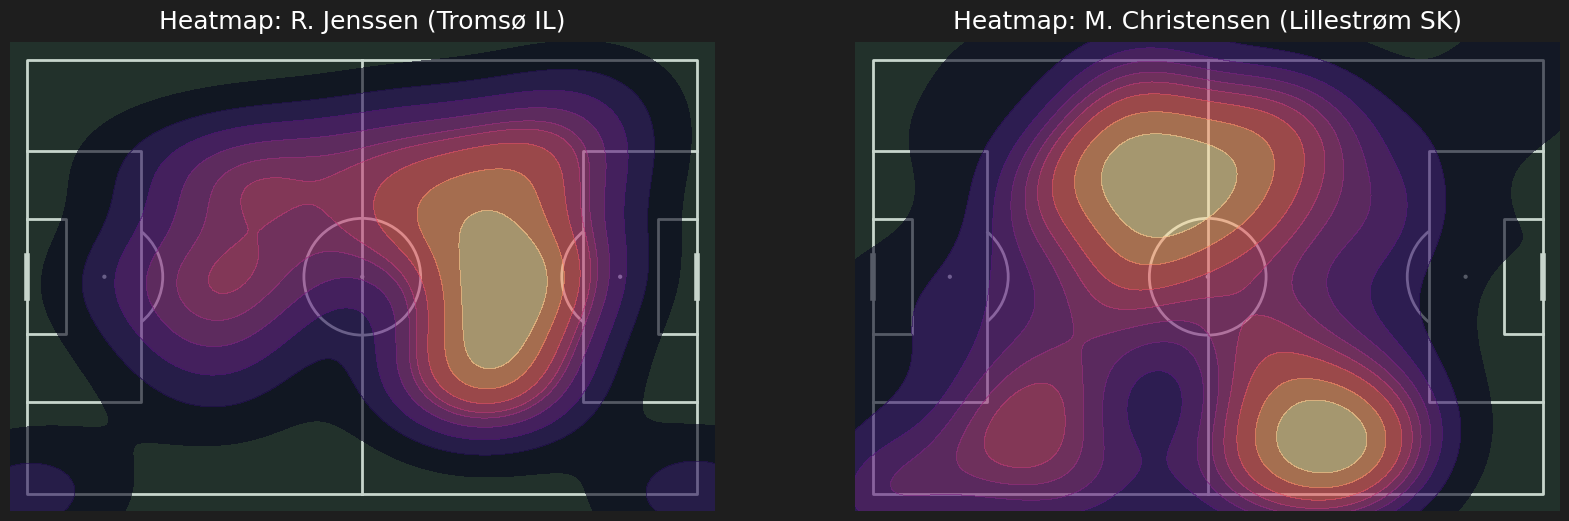

In [ ]:
# 1. Usamos los nombres EXACTOS que detectó tu lista
nombre_tromso = 'R. Jenssen'
nombre_lille = 'M. Christensen'

# 2. Filtramos los datos asegurando que tengan coordenadas
p1_data = df_tromso[df_tromso['playerName'] == nombre_tromso].dropna(subset=['x', 'y'])
p2_data = df_lille[df_lille['playerName'] == nombre_lille].dropna(subset=['x', 'y'])

# 3. Verificación en consola
print(f"Eventos encontrados para {nombre_tromso}: {len(p1_data)}")
print(f"Eventos encontrados para {nombre_lille}: {len(p2_data)}")

# 4. Dibujo de los campos
if len(p1_data) > 0 and len(p2_data) > 0:
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    fig.patch.set_facecolor('#1e1e1e') # Fondo oscuro elegante

    # Configuramos el campo estilo Opta (0-100)
    pitch = Pitch(pitch_type='opta', pitch_color='#22312b', line_color='#c7d5cc')

    # Mapa 1: Tromsø
    pitch.draw(ax=ax[0])
    sns.kdeplot(x=p1_data['x'], y=p1_data['y'], fill=True, thresh=0.05,
                alpha=0.6, cmap='magma', ax=ax[0], bw_adjust=0.8)
    ax[0].set_title(f'Heatmap: {nombre_tromso} (Tromsø IL)', color='white', fontsize=18, pad=10)

    # Mapa 2: Lillestrøm
    pitch.draw(ax=ax[1])
    sns.kdeplot(x=p2_data['x'], y=p2_data['y'], fill=True, thresh=0.05,
                alpha=0.6, cmap='magma', ax=ax[1], bw_adjust=0.8)
    ax[1].set_title(f'Heatmap: {nombre_lille} (Lillestrøm SK)', color='white', fontsize=18, pad=10)

    plt.show()
else:
    print("⚠️ Sigue sin haber datos. Comprueba que las columnas 'x' e 'y' no estén vacías en el CSV.")

Testing out my data with these heat maps.

Discovering team ID´s


In [ ]:
ids_detectados = df_eventos['contestantId'].unique()
print("📋 LISTA DE IDs ENCONTRADOS:")
for i, team_id in enumerate(ids_detectados):
    if str(team_id) != 'nan':
        print(f"ID {i+1}: '{team_id}'")

📋 LISTA DE IDs ENCONTRADOS:
ID 1: '80hgdmpkvdrhw1ge9nks2kxvy'
ID 2: 'e5txudmuc2qpc460bs4lb5aff'
ID 3: '8q6cv8g4bd3xdl7m88kll16na'
ID 4: 'btaf9fuj3xctycyjeqwereaow'
ID 5: 'ctvzi2jbl1q6xzq0s3sexj73g'
ID 6: 'doohk95o6e8pkqah8vkop51dg'
ID 7: 'c7jgkxx1czv5etn7snf1r6p2m'
ID 8: '45v50owpvshpijizwwlcw4lni'
ID 9: '6oxoag5c6zbnn09wx08vz4iak'
ID 10: 'uqspd1bx7f6mq8ohj50u1k1k'
ID 11: '4q0b35m26thti4c2on9a3npk0'
ID 12: '8njda6ajphczdxo54e348l5ua'
ID 13: 'bsykw9d70ffqe9atosc92n1e9'
ID 14: 'crlocdyqyb1fdhck54qxs65rl'
ID 15: '93xj9vmeln0marv6r1uti7but'
ID 16: '3impprc048nbz39w05s18c6yt'


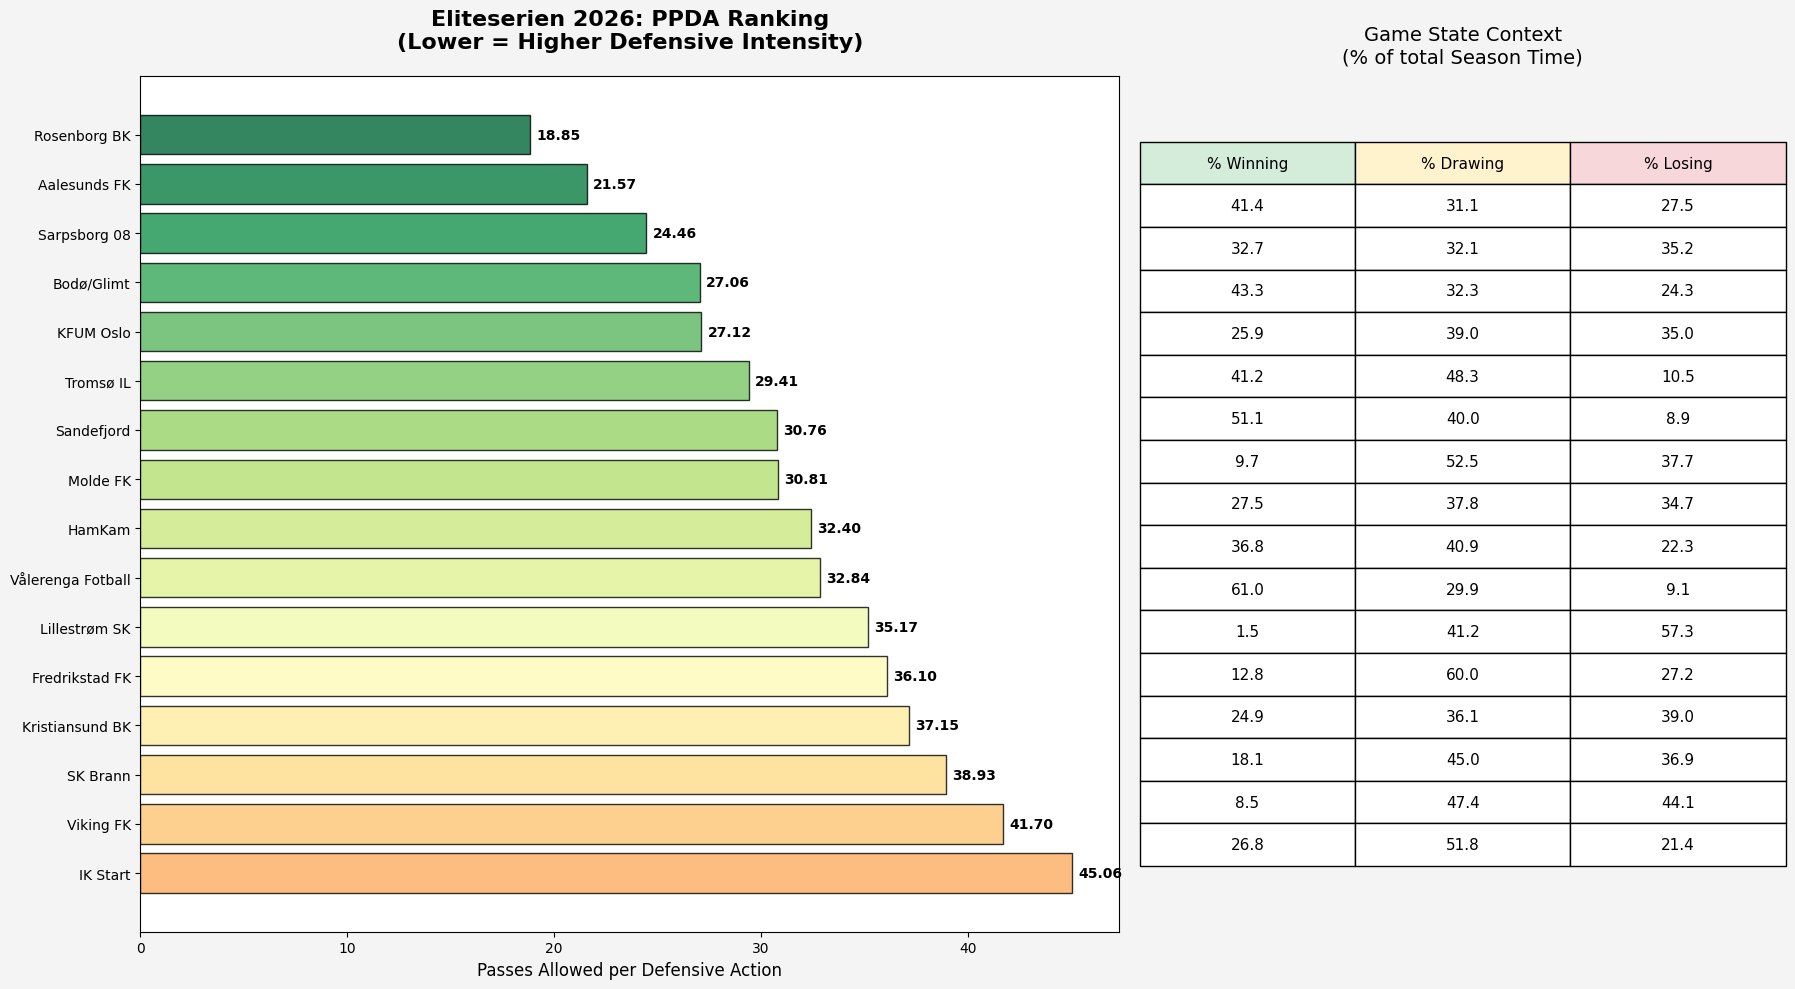

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. DICCIONARIO MAESTRO ELITESERIEN 2026
nombres_equipos = {
    '80hgdmpkvdrhw1ge9nks2kxvy': 'Tromsø IL',
    'e5txudmuc2qpc460bs4lb5aff': 'Lillestrøm SK',
    '8q6cv8g4bd3xdl7m88kll16na': 'Molde FK',
    'btaf9fuj3xctycyjeqwereaow': 'Bodø/Glimt',
    'ctvzi2jbl1q6xzq0s3sexj73g': 'Rosenborg BK',
    'doohk95o6e8pkqah8vkop51dg': 'SK Brann',
    'c7jgkxx1czv5etn7snf1r6p2m': 'Viking FK',
    '45v50owpvshpijizwwlcw4lni': 'Sarpsborg 08',
    '6oxoag5c6zbnn09wx08vz4iak': 'Aalesunds FK',
    'uqspd1bx7f6mq8ohj50u1k1k': 'IK Start',
    '4q0b35m26thti4c2on9a3npk0': 'HamKam',
    '8njda6ajphczdxo54e348l5ua': 'Sandefjord',
    'bsykw9d70ffqe9atosc92n1e9': 'Vålerenga Fotball',
    'crlocdyqyb1fdhck54qxs65rl': 'Kristiansund BK',
    '93xj9vmeln0marv6r1uti7but': 'KFUM Oslo',
    '3impprc048nbz39w05s18c6yt': 'Fredrikstad FK'
}

ruta_maestra = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Eliteserien 2026/'
data_acumulada = []

# IDs de eventos de Opta para acciones defensivas reales
# 7: Tackle, 8: Interception, 10: Foul, 12: Clearance
ACCIONES_DEF_ESTRICTAS = [7, 8, 10, 12]

# 2. PROCESAMIENTO DE ARCHIVOS
for raiz, _, archivos in os.walk(ruta_maestra):
    for archivo in archivos:
        if archivo.endswith('.csv'):
            df = pd.read_csv(os.path.join(raiz, archivo))

            teams = [t for t in df['contestantId'].unique() if str(t) != 'nan']
            if len(teams) < 2: continue
            t1, t2 = teams[0], teams[1]

            # --- Lógica de Tiempo por Marcador (Game State) ---
            goles = df[df['typeId'] == 16].sort_values(['timeMin', 'timeSec'])
            current_score = {t1: 0, t2: 0}
            last_time = 0
            stats_tiempo = {t1: {'win': 0, 'draw': 0, 'lose': 0}, t2: {'win': 0, 'draw': 0, 'lose': 0}}
            match_end = df['timeMin'].max()

            for _, gol in goles.iterrows():
                duracion = gol['timeMin'] - last_time
                for t in [t1, t2]:
                    rival = t2 if t == t1 else t1
                    if current_score[t] > current_score[rival]: stats_tiempo[t]['win'] += duracion
                    elif current_score[t] < current_score[rival]: stats_tiempo[t]['lose'] += duracion
                    else: stats_tiempo[t]['draw'] += duracion
                current_score[gol['contestantId']] += 1
                last_time = gol['timeMin']

            duracion_final = match_end - last_time
            for t in [t1, t2]:
                rival = t2 if t == t1 else t1
                if current_score[t] > current_score[rival]: stats_tiempo[t]['win'] += duracion_final
                elif current_score[t] < current_score[rival]: stats_tiempo[t]['lose'] += duracion_final
                else: stats_tiempo[t]['draw'] += duracion_final

            # --- Lógica de PPDA Corregida ---
            for t in [t1, t2]:
                rival = t2 if t == t1 else t1

                # Acciones defensivas propias en campo contrario (x > 40)
                def_actions = df[(df['contestantId'] == t) &
                                 (df['typeId'].isin(ACCIONES_DEF_ESTRICTAS)) &
                                 (df['x'] > 40)].shape[0]

                # Pases del rival en su propio campo (x < 60)
                opp_passes = df[(df['contestantId'] == rival) &
                                (df['typeId'] == 1) &
                                (df['x'] < 60)].shape[0]

                data_acumulada.append({
                    'id': t,
                    'def_actions': def_actions,
                    'opp_passes': opp_passes,
                    'win_t': stats_tiempo[t]['win'],
                    'draw_t': stats_tiempo[t]['draw'],
                    'lose_t': stats_tiempo[t]['lose']
                })

# 3. CONSOLIDACIÓN DE DATOS
df_final = pd.DataFrame(data_acumulada).groupby('id').sum().reset_index()
df_final['PPDA'] = (df_final['opp_passes'] / df_final['def_actions']).round(2)
df_final['Team'] = df_final['id'].map(nombres_equipos).fillna(df_final['id'])

# Cálculo de porcentajes de tiempo
total_t = df_final['win_t'] + df_final['draw_t'] + df_final['lose_t']
df_final['% Win'] = (df_final['win_t'] / total_t * 100).round(1)
df_final['% Draw'] = (df_final['draw_t'] / total_t * 100).round(1)
df_final['% Lose'] = (df_final['lose_t'] / total_t * 100).round(1)

# Ordenar por PPDA (Menor PPDA = Más intensidad)
df_final = df_final.sort_values('PPDA', ascending=True)

# 4. VISUALIZACIÓN PROFESIONAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [2.5, 1.5]})
fig.patch.set_facecolor('#f4f4f4')

# Gráfico de barras de PPDA
colors = plt.cm.RdYlGn_r(np.linspace(0, 0.7, len(df_final)))
bars = ax1.barh(df_final['Team'], df_final['PPDA'], color=colors, edgecolor='black', alpha=0.8)
ax1.invert_yaxis()
ax1.set_title('Eliteserien 2026: PPDA Ranking\n(Lower = Higher Defensive Intensity)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Passes Allowed per Defensive Action', fontsize=12)

for bar in bars:
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}', va='center', fontweight='bold', color='black')

# Tabla de Game State
ax2.axis('off')
table_columns = ['% Winning', '% Drawing', '% Losing']
table_data = df_final[['% Win', '% Draw', '% Lose']].values
the_table = ax2.table(cellText=table_data, colLabels=table_columns,
                      loc='center', cellLoc='center', colColours=['#d4edda', '#fff3cd', '#f8d7da'])
the_table.auto_set_font_size(False)
the_table.set_fontsize(11)
the_table.scale(1.1, 2.3)
ax2.set_title('Game State Context\n(% of total Season Time)', fontsize=14, pad=10)

plt.tight_layout()
plt.show()

In [ ]:
!pip install Pillow

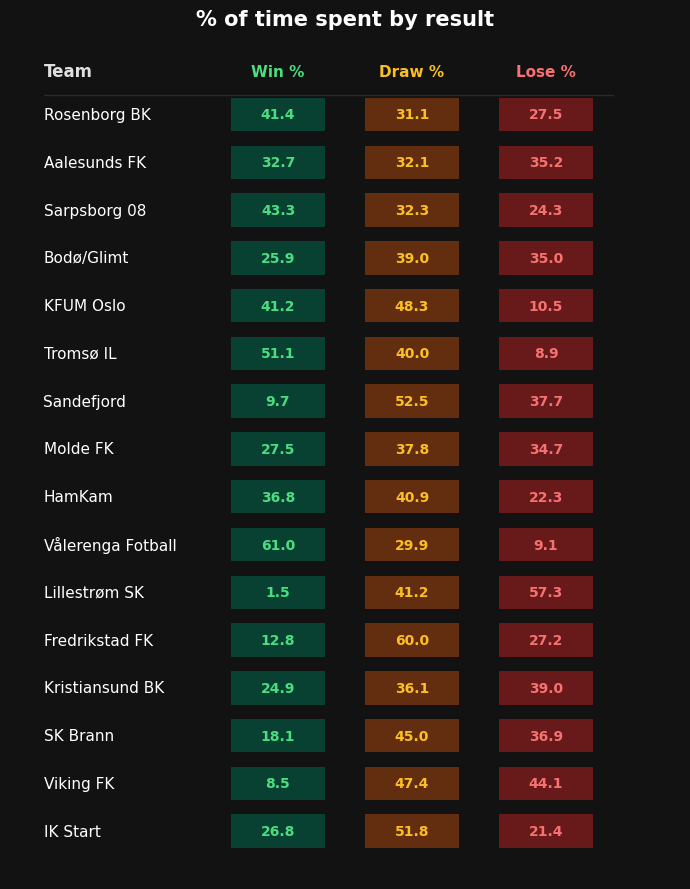

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Asegúrate de que df_final esté ordenado
df_final = df_final.sort_values('PPDA', ascending=True)

# 2. Generar la Tabla Visual en MODO OSCURO
fig_tab, ax_tab = plt.subplots(figsize=(7, 9))
# Color de fondo oscuro elegante
fig_tab.patch.set_facecolor('#121212')
ax_tab.set_facecolor('#121212')

ax_tab.set_xlim(0, 10)
ax_tab.set_ylim(-1, len(df_final))
ax_tab.axis('off')

# Encabezados con colores claros para resaltar sobre el fondo oscuro
header_y = len(df_final) - 0.2
ax_tab.text(0.5, header_y, 'Team', fontweight='bold', ha='left', fontsize=12, color='#E0E0E0')
ax_tab.text(4, header_y, 'Win %', fontweight='bold', ha='center', color='#4ade80', fontsize=11) # Verde neón
ax_tab.text(6, header_y, 'Draw %', fontweight='bold', ha='center', color='#fbbf24', fontsize=11) # Amarillo neón
ax_tab.text(8, header_y, 'Lose %', fontweight='bold', ha='center', color='#f87171', fontsize=11) # Rojo neón

# Dibujar filas
for i, (index, row) in enumerate(df_final.iterrows()):
    y_pos = len(df_final) - 1 - i

    # Nombre del equipo en blanco/gris claro
    ax_tab.text(0.5, y_pos, row['Team'], va='center', fontsize=11, color='#FFFFFF')

    # Celdas de datos con colores ligeramente más saturados para el modo oscuro
    # Columna WIN
    ax_tab.add_patch(plt.Rectangle((3.3, y_pos-0.35), 1.4, 0.7, color='#064e3b', alpha=0.8, ec='none')) # Verde oscuro fondo
    ax_tab.text(4, y_pos, f"{row['% Win']:.1f}", va='center', ha='center', fontsize=10, fontweight='bold', color='#4ade80')

    # Columna DRAW
    ax_tab.add_patch(plt.Rectangle((5.3, y_pos-0.35), 1.4, 0.7, color='#78350f', alpha=0.8, ec='none')) # Ámbar oscuro fondo
    ax_tab.text(6, y_pos, f"{row['% Draw']:.1f}", va='center', ha='center', fontsize=10, fontweight='bold', color='#fbbf24')

    # Columna LOSE
    ax_tab.add_patch(plt.Rectangle((7.3, y_pos-0.35), 1.4, 0.7, color='#7f1d1d', alpha=0.8, ec='none')) # Rojo oscuro fondo
    ax_tab.text(8, y_pos, f"{row['% Lose']:.1f}", va='center', ha='center', fontsize=10, fontweight='bold', color='#f87171')

# Línea de separación sutil
ax_tab.plot([0.5, 9], [header_y-0.4, header_y-0.4], color='#FFFFFF', lw=1, alpha=0.1)

plt.title('% of time spent by result', fontsize=15, fontweight='bold', pad=30, color='#FFFFFF')
plt.tight_layout()
plt.savefig('% of time.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. DICCIONARIO MAESTRO ELITESERIEN 2026
nombres_equipos = {
    '80hgdmpkvdrhw1ge9nks2kxvy': 'Tromsø IL',
    'e5txudmuc2qpc460bs4lb5aff': 'Lillestrøm SK',
    '8q6cv8g4bd3xdl7m88kll16na': 'Molde FK',
    'btaf9fuj3xctycyjeqwereaow': 'Bodø/Glimt',
    'ctvzi2jbl1q6xzq0s3sexj73g': 'Rosenborg BK',
    'doohk95o6e8pkqah8vkop51dg': 'SK Brann',
    'c7jgkxx1czv5etn7snf1r6p2m': 'Viking FK',
    '45v50owpvshpijizwwlcw4lni': 'Sarpsborg 08',
    '6oxoag5c6zbnn09wx08vz4iak': 'Aalesunds FK',
    'uqspd1bx7f6mq8ohj50u1k1k': 'IK Start',
    '4q0b35m26thti4c2on9a3npk0': 'HamKam',
    '8njda6ajphczdxo54e348l5ua': 'Sandefjord',
    'bsykw9d70ffqe9atosc92n1e9': 'Vålerenga Fotball',
    'crlocdyqyb1fdhck54qxs65rl': 'Kristiansund BK',
    '93xj9vmeln0marv6r1uti7but': 'KFUM Oslo',
    '3impprc048nbz39w05s18c6yt': 'Fredrikstad FK'
}

ruta_maestra = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Eliteserien 2026/'
data_acumulada = []

# IDs de eventos de Opta para acciones defensivas reales
# 7: Tackle, 8: Interception, 10: Foul, 12: Clearance
ACCIONES_DEF_ESTRICTAS = [7, 8, 10, 12]

# 2. PROCESAMIENTO DE ARCHIVOS
for raiz, _, archivos in os.walk(ruta_maestra):
    for archivo in archivos:
        if archivo.endswith('.csv'):
            df = pd.read_csv(os.path.join(raiz, archivo))

            teams = [t for t in df['contestantId'].unique() if str(t) != 'nan']
            if len(teams) < 2: continue
            t1, t2 = teams[0], teams[1]

            # --- Lógica de Tiempo por Marcador (Game State) ---
            goles = df[df['typeId'] == 16].sort_values(['timeMin', 'timeSec'])
            current_score = {t1: 0, t2: 0}
            last_time = 0
            stats_tiempo = {t1: {'win': 0, 'draw': 0, 'lose': 0}, t2: {'win': 0, 'draw': 0, 'lose': 0}}
            match_end = df['timeMin'].max()

            for _, gol in goles.iterrows():
                duracion = gol['timeMin'] - last_time
                for t in [t1, t2]:
                    rival = t2 if t == t1 else t1
                    if current_score[t] > current_score[rival]: stats_tiempo[t]['win'] += duracion
                    elif current_score[t] < current_score[rival]: stats_tiempo[t]['lose'] += duracion
                    else: stats_tiempo[t]['draw'] += duracion
                current_score[gol['contestantId']] += 1
                last_time = gol['timeMin']

            duracion_final = match_end - last_time
            for t in [t1, t2]:
                rival = t2 if t == t1 else t1
                if current_score[t] > current_score[rival]: stats_tiempo[t]['win'] += duracion_final
                elif current_score[t] < current_score[rival]: stats_tiempo[t]['lose'] += duracion_final
                else: stats_tiempo[t]['draw'] += duracion_final

            # --- Lógica de PPDA Corregida ---
            for t in [t1, t2]:
                rival = t2 if t == t1 else t1

                # Acciones defensivas propias en campo contrario (x > 40)
                def_actions = df[(df['contestantId'] == t) &
                                 (df['typeId'].isin(ACCIONES_DEF_ESTRICTAS)) &
                                 (df['x'] > 40)].shape[0]

                # Pases del rival en su propio campo (x < 60)
                opp_passes = df[(df['contestantId'] == rival) &
                                (df['typeId'] == 1) &
                                (df['x'] < 60)].shape[0]

                data_acumulada.append({
                    'id': t,
                    'def_actions': def_actions,
                    'opp_passes': opp_passes,
                    'win_t': stats_tiempo[t]['win'],
                    'draw_t': stats_tiempo[t]['draw'],
                    'lose_t': stats_tiempo[t]['lose']
                })

# 3. CONSOLIDACIÓN DE DATOS
df_final = pd.DataFrame(data_acumulada).groupby('id').sum().reset_index()
df_final['PPDA'] = (df_final['opp_passes'] / df_final['def_actions']).round(2)
df_final['Team'] = df_final['id'].map(nombres_equipos).fillna(df_final['id'])

# Cálculo de porcentajes de tiempo
total_t = df_final['win_t'] + df_final['draw_t'] + df_final['lose_t']
df_final['% Win'] = (df_final['win_t'] / total_t * 100).round(1)
df_final['% Draw'] = (df_final['draw_t'] / total_t * 100).round(1)
df_final['% Lose'] = (df_final['lose_t'] / total_t * 100).round(1)

# Ordenar por PPDA (Menor PPDA = Más intensidad)
df_final = df_final.sort_values('PPDA', ascending=True)

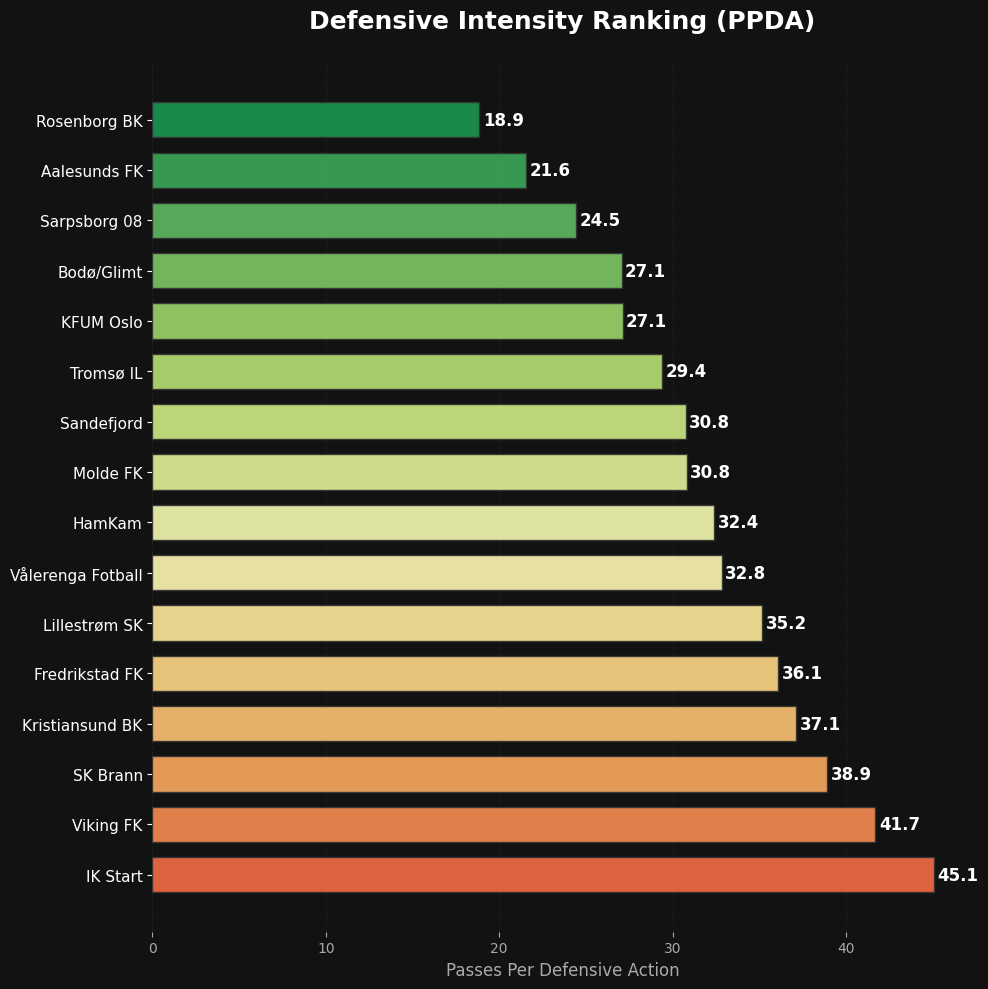

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Asegúrate de que df_final esté ordenado por PPDA
df_final = df_final.sort_values('PPDA', ascending=True)

# Usamos un estilo base para limpieza general, pero lo personalizaremos
plt.style.use('default')

# 2. Generar el Gráfico de PPDA en MODO OSCURO (Corregido)
fig_bar, ax_bar = plt.subplots(figsize=(10, 10))

# Color de fondo oscuro elegante (mismo que la tabla)
FONDO_OSCURO = '#121212'
TEXTO_PRINCIPAL = '#FFFFFF'
TEXTO_SECUNDARIO = '#AAAAAA'

fig_bar.patch.set_facecolor(FONDO_OSCURO)
ax_bar.set_facecolor(FONDO_OSCURO)

# Colores de las barras: degradado que brille bien en el fondo oscuro
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.8, len(df_final)))

# Dibujamos las barras con un zorder alto para que estén al frente
bars = ax_bar.barh(df_final['Team'], df_final['PPDA'], color=colors, alpha=0.9,
                   edgecolor='#333333', height=0.7, zorder=3)

# Añadir los valores de PPDA al final de cada barra con un zorder aún mayor
for bar in bars:
    width = bar.get_width()
    # Evitamos superposiciones si el valor es muy bajo
    text_pos_x = width + 0.2 if width > 0.5 else width + 0.05
    ax_bar.text(text_pos_x, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}',
                va='center', fontweight='bold', fontsize=12,
                color=TEXTO_PRINCIPAL, zorder=5)

# Invertir eje para que el mejor (menor PPDA) esté arriba
ax_bar.invert_yaxis()

# Configuración de ejes y etiquetas
ax_bar.set_title('Defensive Intensity Ranking (PPDA)', fontsize=18, fontweight='bold',
                 pad=25, color=TEXTO_PRINCIPAL)
ax_bar.set_xlabel('Passes Per Defensive Action',
                 fontsize=12, color=TEXTO_SECUNDARIO)

# Estilo de los nombres de los equipos
ax_bar.tick_params(axis='y', colors=TEXTO_PRINCIPAL, labelsize=11)
ax_bar.tick_params(axis='x', colors=TEXTO_SECUNDARIO)

# --- CORRECCIÓN DE LA REJILLA (GRID) ---
# zorder=0 asegura que la rejilla se pinte en la capa del fondo
ax_bar.grid(axis='x', linestyle='--', alpha=0.05, color=TEXTO_PRINCIPAL, zorder=0)

# Quitar los bordes de la caja del gráfico para un look más moderno
for spine in ax_bar.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('PPDA.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
# Carga un archivo cualquiera de tu carpeta
df_temp = pd.read_csv('/content/drive/MyDrive/TFM_Analisis_de_Datos/Eliteserien 2026/Matchday 01/MD1_Aalesund_vs_Lillestrom_events.csv')
print(df_temp.columns.tolist())

['id', 'eventId', 'typeId', 'periodId', 'timeMin', 'timeSec', 'contestantId', 'playerId', 'playerName', 'outcome', 'keyPass', 'x', 'y', 'timeStamp', 'lastModified', 'qualifier_1', 'qualifier_2', 'qualifier_3', 'qualifier_4', 'qualifier_5', 'qualifier_6', 'qualifier_7', 'qualifier_9', 'qualifier_13', 'qualifier_15', 'qualifier_16', 'qualifier_17', 'qualifier_18', 'qualifier_20', 'qualifier_22', 'qualifier_23', 'qualifier_24', 'qualifier_25', 'qualifier_29', 'qualifier_30', 'qualifier_31', 'qualifier_41', 'qualifier_42', 'qualifier_44', 'qualifier_53', 'qualifier_55', 'qualifier_56', 'qualifier_57', 'qualifier_59', 'qualifier_60', 'qualifier_61', 'qualifier_63', 'qualifier_64', 'qualifier_72', 'qualifier_73', 'qualifier_74', 'qualifier_75', 'qualifier_76', 'qualifier_77', 'qualifier_78', 'qualifier_79', 'qualifier_80', 'qualifier_81', 'qualifier_82', 'qualifier_85', 'qualifier_86', 'qualifier_88', 'qualifier_89', 'qualifier_94', 'qualifier_102', 'qualifier_103', 'qualifier_107', 'qualifi

In [ ]:
!pip install adjust_text

ERROR: Could not find a version that satisfies the requirement adjust_text (from versions: none)
ERROR: No matching distribution found for adjust_text


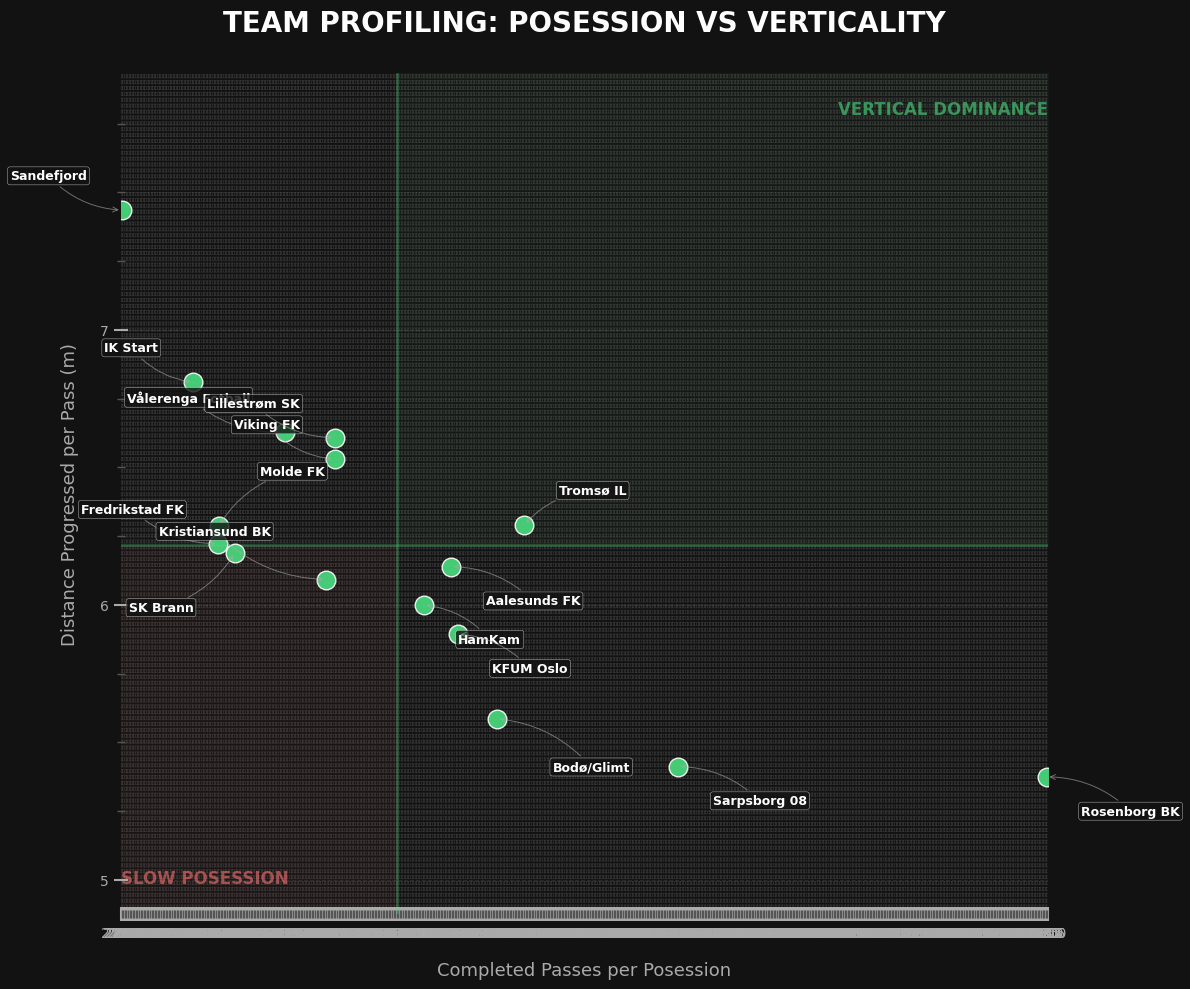

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- NEW CODE TO CREATE df_estilo ---
# 1. Filter for completed passes (typeId == 1, outcome == True)
passes_df = df_eventos[(df_eventos['typeId'] == 1) & (df_eventos['outcome'] == True)].copy()

# 2. Calculate progressive distance for each pass
# Assuming 'x' is start_x and 'qualifier_140' is end_x (common in Opta data)
passes_df['progressive_distance'] = passes_df.apply(
    lambda row: max(0, row['qualifier_140'] - row['x']) if pd.notna(row['qualifier_140']) and pd.notna(row['x']) else 0,
    axis=1
)

# 3. Aggregate by contestantId
team_stats = passes_df.groupby('contestantId').agg(
    total_completed_passes=('id', 'count'),
    total_progressive_distance=('progressive_distance', 'sum')
).reset_index()

# Rename 'contestantId' to 'id' to match df_final
team_stats = team_stats.rename(columns={'contestantId': 'id'})

# 4. Merge with df_final to get total_minutes (win_t + draw_t + lose_t) and Team names
# Ensure 'id' column exists in df_final or use a relevant merge key
# Assuming df_final contains 'id', 'win_t', 'draw_t', 'lose_t', and 'Team' as per previous cells.
df_estilo = pd.merge(team_stats, df_final[['id', 'win_t', 'draw_t', 'lose_t', 'Team']], on='id', how='left')

# Calculate total minutes played for normalization
df_estilo['total_minutes'] = df_estilo['win_t'] + df_estilo['draw_t'] + df_estilo['lose_t']

# 5. Calculate pases_por_pos and prog_por_pase
# pases_por_pos: Average completed passes per 90 minutes (normalized by games played)
df_estilo['pases_por_pos'] = (df_estilo['total_completed_passes'] / df_estilo['total_minutes'] * 90).fillna(0)
# prog_por_pase: Total progressive distance per completed pass
df_estilo['prog_por_pase'] = (df_estilo['total_progressive_distance'] / df_estilo['total_completed_passes']).fillna(0)

# Clean up infinite values if any division by zero occurs
df_estilo = df_estilo.replace([np.inf, -np.inf], np.nan).fillna(0)


# 1. Configuración de estilo (Se mantiene igual para coherencia)
FONDO = '#121212'
VERDE_PUNTO = '#4ade80'
GRIS_TEXTO = '#AAAAAA'

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(FONDO)
ax.set_facecolor(FONDO)

# 2. Ajuste de Rangos y Medias
x_min, x_max = df_estilo['pases_por_pos'].min() - 0.3, df_estilo['pases_por_pos'].max() + 0.6
y_min, y_max = df_estilo['prog_por_pase'].min() - 0.5, df_estilo['prog_por_pase'].max() + 0.5
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
mx, my = df_estilo['pases_por_pos'].mean(), df_estilo['prog_por_pase'].mean()

# 3. PUNTOS
ax.scatter(df_estilo['pases_por_pos'], df_estilo['prog_por_pase'],
           s=180, c=VERDE_PUNTO, alpha=0.9, edgecolors='white', lw=1, zorder=10)

# 4. GESTIÓN DE ETIQUETAS CON AJUSTE ESPECÍFICO
for i, row in df_estilo.reset_index().iterrows():
    team = row['Team']
    x, y = row['pases_por_pos'], row['prog_por_pase']

    # Configuración base por cuadrante
    ha = 'left' if x > mx else 'right'
    va = 'bottom' if y > my else 'top'
    dist_x = 25 if x > mx else -25
    dist_y = 20 if y > my else -20

    # --- AJUSTES MANUALES PARA EQUIPOS SOLAPADOS ---
    if 'Kristiansund' in team:
        dist_x, dist_y = -40, 30  # Lo movemos arriba a la izquierda
        ha, va = 'right', 'bottom'
    elif 'Bodø/Glimt' in team:
        dist_x, dist_y = 40, -30  # Lo movemos abajo a la derecha
        ha, va = 'left', 'top'
    elif 'Brann' in team:
        dist_x, dist_y = -30, -35 # Un poco más abajo
        ha, va = 'right', 'top'
    elif 'Molde' in team:
        dist_x, dist_y = 30, 35   # Un poco más arriba
        ha, va = 'left', 'bottom'

    ax.annotate(team,
                (x, y),
                xytext=(dist_x, dist_y),
                textcoords='offset points',
                ha=ha, va=va,
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc=FONDO, ec='white', lw=0.3, alpha=0.8),
                arrowprops=dict(arrowstyle='->', color=GRIS_TEXTO, lw=0.7,
                                connectionstyle="arc3,rad=0.2", alpha=0.6), # Rad mayor para curvas más claras
                zorder=12)

# 5. REJILLAS Y MARCAS (Visibilidad Total)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

ax.grid(which='major', color='#FFFFFF', linestyle='--', alpha=0.1, zorder=1)
ax.grid(which='minor', color='#FFFFFF', linestyle=':', alpha=0.07, zorder=1)

ax.tick_params(axis='both', which='major', colors=GRIS_TEXTO, length=10, width=1.5, direction='inout')
ax.tick_params(axis='both', which='minor', colors='#555555', length=6, width=1, direction='inout')

# 6. LÍNEAS DE MEDIA Y SOMBREADO
ax.axvline(mx, color=VERDE_PUNTO, linestyle='-', alpha=0.3, lw=2)
ax.axhline(my, color=VERDE_PUNTO, linestyle='-', alpha=0.3, lw=2)
ax.fill_between([mx, x_max], my, y_max, color=VERDE_PUNTO, alpha=0.04)
ax.fill_between([x_min, mx], y_min, my, color='#f87171', alpha=0.04)

# 7. TEXTOS DE CATEGORÍA
ax.text(x_max-0.1, y_max-0.1, "VERTICAL DOMINANCE", color=VERDE_PUNTO, fontsize=12, fontweight='black', ha='right', va='top', alpha=0.6)
ax.text(x_min+0.1, y_min+0.1, "SLOW POSESSION", color='#f87171', fontsize=12, fontweight='black', ha='left', va='bottom', alpha=0.6)

for s in ax.spines.values(): s.set_visible(False)

ax.set_title('TEAM PROFILING: POSESSION VS VERTICALITY', fontsize=20, fontweight='bold', color='white', pad=30)
ax.set_xlabel('Completed Passes per Posession', color=GRIS_TEXTO, fontsize=13, labelpad=15)
ax.set_ylabel('Distance Progressed per Pass (m)', color=GRIS_TEXTO, fontsize=13, labelpad=15)

plt.tight_layout()
plt.savefig('Scatter Chart.png', dpi=300, bbox_inches='tight')
plt.show()

Final version of scatter chart, above.
Trying to fix it, below.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. FUNCIÓN DE LIMPIEZA (Para asegurar que los 16 equipos aparezcan)
def normalizar_nombres(nombre):
    n = str(nombre).strip().lower()
    if n == 'nan' or n == '' or "bod" in n or "glim" in n: return "F. K. Bodø/Glimt"
    if "troms" in n: return "Tromsø IL"
    if "lillest" in n: return "Lillestrøm SK"
    if "viking" in n: return "Viking FK"
    if "molde" in n: return "Molde FK"
    if "våler" in n or "valer" in n: return "Vålerenga Fotball"
    if "sandefj" in n: return "Sandefjord"
    if "fredrik" in n: return "Fredrikstad FK"
    if "hamkam" in n: return "HamKam"
    if "kristian" in n: return "Kristiansund BK"
    if "sarps" in n: return "Sarpsborg 08"
    if "kfum" in n: return "KFUM Oslo"
    if "rosenb" in n: return "Rosenborg BK"
    if "brann" in n: return "SK Brann"
    if "start" in n: return "IK Start"
    if "aales" in n: return "Aalesunds FK"
    return nombre

# 2. PROCESAMIENTO
# The df_estilo DataFrame is already prepared from the previous cell (0ew99934N66s)
# It contains 'Team', 'pases_por_pos', and 'prog_por_pase'

# 3. DISEÑO DEL GRÁFICO
fig, ax = plt.subplots(figsize=(13, 13))
fig.patch.set_facecolor('#0b0b0b')
ax.set_facecolor('#0b0b0b')

x = df_estilo['pases_por_pos']
y = df_estilo['prog_por_pase']
teams = df_estilo['Team']

# Calculamos las medias para situar los cuadrantes
x_mean = x.mean()
y_mean = y.mean()

# Dibujamos las cruces de los cuadrantes
ax.axvline(x_mean, color='white', linestyle='--', alpha=0.3, lw=1.5, zorder=1)
ax.axhline(y_mean, color='white', linestyle='--', alpha=0.3, lw=1.5, zorder=1)

# Dibujamos los puntos (Scatter)
ax.scatter(x, y, s=280, c='#22c55e', edgecolors='white', linewidth=1.5, alpha=0.9, zorder=3)

# Añadimos los nombres de los equipos
for i, team in enumerate(teams):
    ax.text(x.iloc[i], y.iloc[i] + 0.015, team.upper(),
            color='white', fontsize=10, ha='center', fontweight='black', zorder=4)

# 4. ETIQUETAS TÁCTICAS DE LOS CUADRANTES
# Situamos el texto en las esquinas para definir el estilo
ax.text(ax.get_xlim()[1]*0.98, ax.get_ylim()[1]*0.98, 'POSESIÓN AVANZADA / DIRECTA',
        color='#555555', fontsize=14, ha='right', va='top', fontweight='black', alpha=0.7)

ax.text(ax.get_xlim()[0]*1.02, ax.get_ylim()[1]*0.98, 'POSESIÓN RÁPIDA / VERTICAL',
        color='#555555', fontsize=14, ha='left', va='top', fontweight='black', alpha=0.7)

ax.text(ax.get_xlim()[0]*1.02, ax.get_ylim()[0]*1.02, 'POSESIÓN LENTA / HORIZONTAL',
        color='#555555', fontsize=14, ha='left', va='bottom', fontweight='black', alpha=0.7)

ax.text(ax.get_xlim()[1]*0.98, ax.get_ylim()[0]*1.02, 'POSESIÓN PACIENTE / ELABORADA',
        color='#555555', fontsize=14, ha='right', va='bottom', fontweight='black', alpha=0.7)

# 5. ESTÉTICA FINAL Y EJES
ax.set_xlabel('PASES COMPLETADOS POR POSESIÓN', color='white', fontsize=13, fontweight='bold', labelpad=20)
ax.set_ylabel('DISTANCIA PROGRESADA POR PASE (m)', color='white', fontsize=13, fontweight='bold', labelpad=20)

plt.title('ESTILO DE POSESIÓN: ELITESERIEN 2026\nAnálisis de Elaboración vs Velocidad',
          color='white', fontsize=22, fontweight='black', pad=40)

# Ajuste de colores de los ejes y rejilla
ax.tick_params(colors='white', labelsize=11)
ax.grid(color='#333333', linestyle=':', alpha=0.4)

for spine in ax.spines.values():
    spine.set_edgecolor('#444444')

# Guardar la versión final
plt.savefig('scatter_estilo_posesion_final.png', dpi=300, bbox_inches='tight', facecolor='#0b0b0b')
plt.show()

KeyError: "Column(s) ['direct_speed', 'passes_per_sequence'] do not exist"

In [ ]:
print(df_eventos.columns.tolist())

['id', 'eventId', 'typeId', 'periodId', 'timeMin', 'timeSec', 'contestantId', 'playerId', 'playerName', 'outcome', 'keyPass', 'x', 'y', 'timeStamp', 'lastModified', 'qualifier_1', 'qualifier_2', 'qualifier_3', 'qualifier_4', 'qualifier_5', 'qualifier_6', 'qualifier_10', 'qualifier_13', 'qualifier_14', 'qualifier_15', 'qualifier_16', 'qualifier_17', 'qualifier_18', 'qualifier_20', 'qualifier_22', 'qualifier_23', 'qualifier_24', 'qualifier_25', 'qualifier_29', 'qualifier_30', 'qualifier_31', 'qualifier_42', 'qualifier_44', 'qualifier_55', 'qualifier_56', 'qualifier_57', 'qualifier_59', 'qualifier_60', 'qualifier_63', 'qualifier_72', 'qualifier_73', 'qualifier_74', 'qualifier_75', 'qualifier_76', 'qualifier_78', 'qualifier_80', 'qualifier_81', 'qualifier_82', 'qualifier_83', 'qualifier_89', 'qualifier_94', 'qualifier_100', 'qualifier_102', 'qualifier_103', 'qualifier_107', 'qualifier_108', 'qualifier_120', 'qualifier_123', 'qualifier_124', 'qualifier_127', 'qualifier_130', 'qualifier_131'

In [ ]:
import pandas as pd
import numpy as np

def calcular_metricas_estilo(df):
    # 1. Definir qué es un pase exitoso (Type 1 es pase en Opta, Outcome 1 es éxito)
    df['is_pass'] = (df['typeId'] == 1) & (df['outcome'] == 1)

    # 2. Identificar secuencias (posiciones seguidas del mismo equipo)
    # Una secuencia cambia cuando cambia el equipo o el periodo
    df['sequence_change'] = (df['contestantId'] != df['contestantId'].shift(1)) | (df['periodId'] != df['periodId'].shift(1))
    df['sequence_id'] = df['sequence_change'].cumsum()

    # 3. Calcular pases por secuencia
    passes_per_seq = df[df['is_pass']].groupby(['sequence_id', 'Team_Clean']).size().reset_index(name='pass_count')
    team_passes = passes_per_seq.groupby('Team_Clean')['pass_count'].mean().reset_index(name='passes_per_sequence')

    # 4. Calcular Velocidad Directa (m/s)
    # Necesitamos el tiempo y la progresión en X (Opta usa 0-100)
    # Filtramos secuencias que tengan al menos 2 eventos para medir tiempo
    seq_stats = df.groupby('sequence_id').agg({
        'Team_Clean': 'first',
        'timeMin': ['first', 'last'],
        'timeSec': ['first', 'last'],
        'x': ['first', 'last']
    })

    # Aplanar columnas
    seq_stats.columns = ['Team_Clean', 'min_start', 'min_end', 'sec_start', 'sec_end', 'x_start', 'x_end']

    # Calcular duración en segundos y distancia en metros (aprox 105m de campo)
    seq_stats['duration'] = (seq_stats['min_end'] * 60 + seq_stats['sec_end']) - (seq_stats['min_start'] * 60 + seq_stats['sec_start'])
    seq_stats['dist_x'] = (seq_stats['x_end'] - seq_stats['x_start']) * 1.05 # Conversión a metros

    # Solo secuencias con duración positiva y que avancen
    seq_stats = seq_stats[seq_stats['duration'] > 0]
    seq_stats['speed'] = seq_stats['dist_x'] / seq_stats['duration']

    team_speed = seq_stats.groupby('Team_Clean')['speed'].mean().reset_index(name='direct_speed')

    # 5. Unir métricas
    df_estilo_final = pd.merge(team_passes, team_speed, on='Team_Clean')
    return df_estilo_final

# Ejecutamos el cálculo
df_estilo = calcular_metricas_estilo(df_eventos)
print("✅ Métricas de estilo calculadas con éxito.")
print(df_estilo.head())

/tmp/ipykernel_3240/2612801070.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_pass'] = (df['typeId'] == 1) & (df['outcome'] == 1)
/tmp/ipykernel_3240/2612801070.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sequence_change'] = (df['contestantId'] != df['contestantId'].shift(1)) | (df['periodId'] != df['periodId'].shift(1))
/tmp/ipykernel_3240/2612801070.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  C

✅ Métricas de estilo calculadas con éxito.
         Team_Clean  passes_per_sequence  direct_speed
0      Aalesunds FK             3.286145      1.211656
1  F. K. Bodø/Glimt             3.715000      2.079711
2    Fredrikstad FK             3.040843      1.649949
3            HamKam             3.655527      1.791570
4          IK Start             3.494565      1.772994


In [ ]:
import pandas as pd
import numpy as np

def calcular_metricas_tfm(df):
    # 1. Identificar pases completados
    df['is_pass'] = (df['typeId'] == 1) & (df['outcome'] == 1)

    # 2. Identificar secuencias (posesiones)
    df['sequence_change'] = (df['contestantId'] != df['contestantId'].shift(1)) | (df['periodId'] != df['periodId'].shift(1))
    df['sequence_id'] = df['sequence_change'].cumsum()

    # --- EJE X: PASES POR POSESIÓN ---
    passes_per_seq = df[df['is_pass']].groupby(['sequence_id', 'Team_Clean']).size().reset_index(name='pass_count')
    team_x = passes_per_seq.groupby('Team_Clean')['pass_count'].mean().reset_index(name='pases_por_posesion')

    # --- EJE Y: DISTANCIA VERTICAL POR PASE ---
    # Calculamos la diferencia en 'x' entre el inicio y fin de cada pase
    # En Opta, 'x' es la verticalidad (0-100).
    # Usamos shift para encontrar el destino del pase (o qualifiers si los tienes, pero x_dest es más fiable)
    pases_df = df[df['is_pass']].copy()

    # Asumimos que el siguiente evento en la misma secuencia es el destino del pase
    pases_df['x_dest'] = pases_df['x'].shift(-1)
    pases_df['dist_vertical'] = (pases_df['x_dest'] - pases_df['x']) * 1.05 # Conversión a metros (aprox)

    # Solo pases que ocurren dentro de la misma secuencia
    pases_df['next_seq'] = pases_df['sequence_id'].shift(-1)
    pases_df = pases_df[pases_df['sequence_id'] == pases_df['next_seq']]

    # Agrupamos por equipo (media de metros ganados por pase)
    team_y = pases_df.groupby('Team_Clean')['dist_vertical'].mean().reset_index(name='distancia_por_pase')

    # Unimos
    df_estilo_final = pd.merge(team_x, team_y, on='Team_Clean')
    return df_estilo_final

df_estilo = calcular_metricas_tfm(df_eventos)
print("✅ Métricas corregidas: Pases por Posesión y Distancia Vertical por Pase.")

✅ Métricas corregidas: Pases por Posesión y Distancia Vertical por Pase.


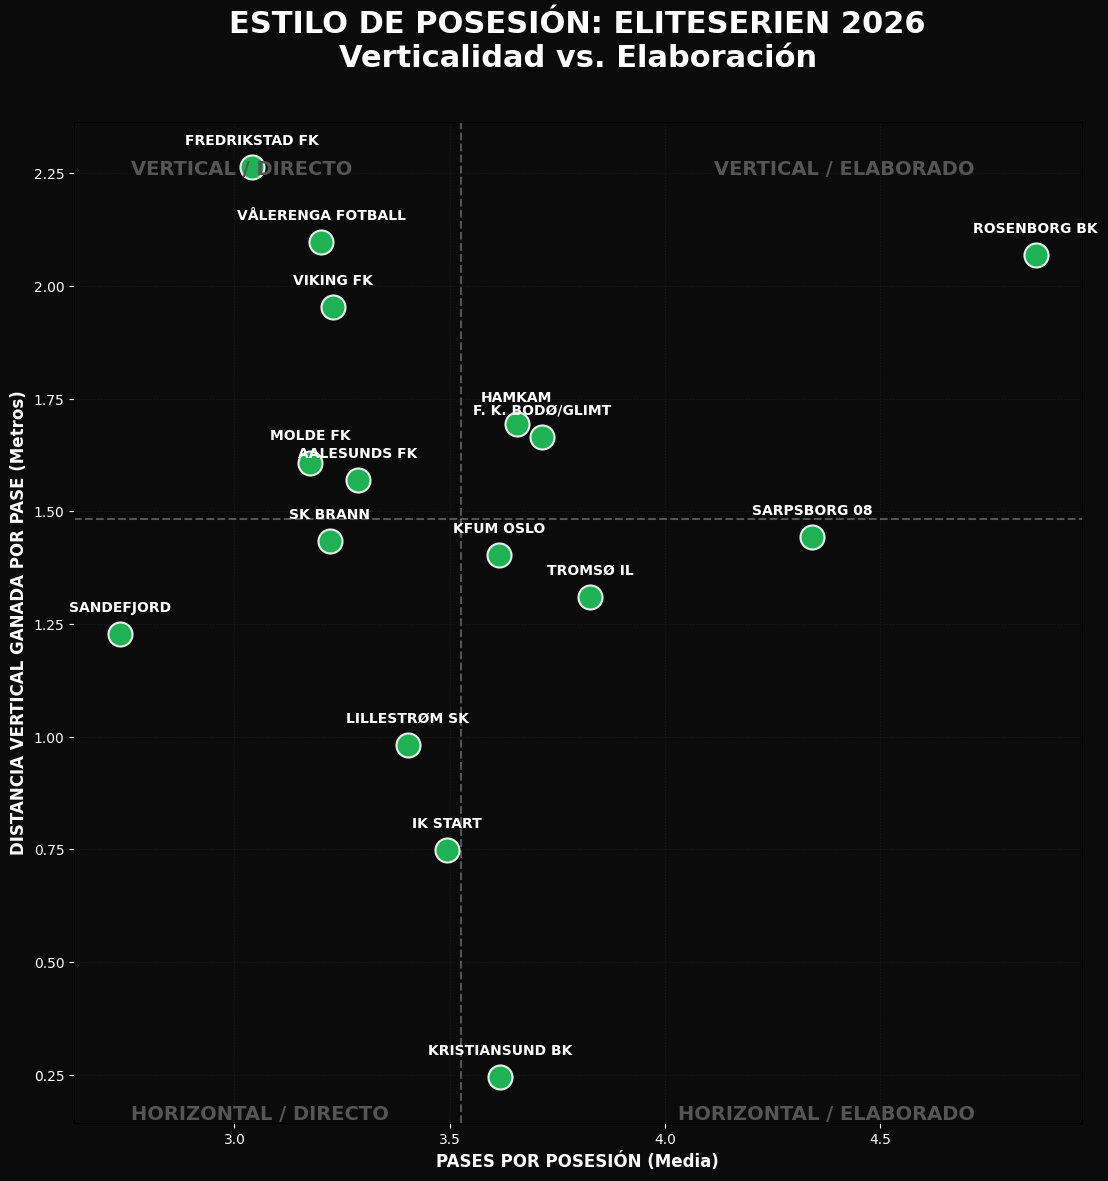

In [ ]:
fig, ax = plt.subplots(figsize=(13, 13))
fig.patch.set_facecolor('#0b0b0b')
ax.set_facecolor('#0b0b0b')

x = df_estilo['pases_por_posesion']
y = df_estilo['distancia_por_pase']
teams = df_estilo['Team_Clean']

# Medias dinámicas
ax.axvline(x.mean(), color='white', linestyle='--', alpha=0.3, lw=1.5)
ax.axhline(y.mean(), color='white', linestyle='--', alpha=0.3, lw=1.5)

# Scatter
ax.scatter(x, y, s=300, c='#22c55e', edgecolors='white', linewidth=1.5, alpha=0.9, zorder=3)

# Etiquetas
for i, team in enumerate(teams):
    ax.text(x.iloc[i], y.iloc[i] + 0.05, team.upper(), color='white', fontsize=10, ha='center', fontweight='black')

# Definiciones de Estilo en las esquinas
ax.text(ax.get_xlim()[1]*0.95, ax.get_ylim()[1]*0.95, 'VERTICAL / ELABORADO', color='#555555', fontsize=14, ha='right', fontweight='black')
ax.text(ax.get_xlim()[0]*1.05, ax.get_ylim()[1]*0.95, 'VERTICAL / DIRECTO', color='#555555', fontsize=14, ha='left', fontweight='black')
ax.text(ax.get_xlim()[0]*1.05, ax.get_ylim()[0]*1.05, 'HORIZONTAL / DIRECTO', color='#555555', fontsize=14, ha='left', fontweight='black')
ax.text(ax.get_xlim()[1]*0.95, ax.get_ylim()[0]*1.05, 'HORIZONTAL / ELABORADO', color='#555555', fontsize=14, ha='right', fontweight='black')

ax.set_xlabel('PASES POR POSESIÓN (Media)', color='white', fontsize=12, fontweight='bold')
ax.set_ylabel('DISTANCIA VERTICAL GANADA POR PASE (Metros)', color='white', fontsize=12, fontweight='bold')
plt.title('ESTILO DE POSESIÓN: ELITESERIEN 2026\nVerticalidad vs. Elaboración', color='white', fontsize=22, fontweight='black', pad=40)

ax.tick_params(colors='white')
ax.grid(color='#333333', linestyle=':', alpha=0.4)
plt.show()

Lollipop radar

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. Configuración de Colores (Rojo -> Verde)
colores_semaforo = ["#ef4444", "#f97316", "#facc15", "#22c55e"]
mi_cmap = LinearSegmentedColormap.from_list("semaforo", colores_semaforo)

# 2. Datos (Asumimos df_resultados ya calculado)
df_resultados = df_resultados.sort_values('ratio', ascending=True)
teams = df_resultados['Team'].tolist()
values = df_resultados['ratio'].tolist()
num_teams = len(teams)
angles = np.linspace(0, 2 * np.pi, num_teams, endpoint=False).tolist()

# 3. Configuración del lienzo
fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0b0b0b')
ax.set_facecolor('#0b0b0b')

norm = plt.Normalize(min(values), max(values))
colores_barras = [mi_cmap(norm(v)) for v in values]

# 4. Lollipops con brillo
ax.vlines(angles, 0, values, color=colores_barras, linewidth=5, alpha=0.15)
ax.vlines(angles, 0, values, color=colores_barras, linewidth=2, alpha=0.8)
ax.scatter(angles, values, color=colores_barras, s=180, edgecolor='white', lw=1, zorder=10)

# 5. GUÍAS VISIBLES (La "Telaraña") Y VALORES EJE VERTICAL
max_val = max(values)
grid_values = np.linspace(0, max_val, 6)[1:] # 5 niveles de red

for g in grid_values:
    # La línea circular
    ax.axhline(g, color='white', linestyle=(0, (5, 10)), alpha=0.2, lw=1, zorder=1)

    # Valor hacia ARRIBA (Norte - 90°)
    ax.text(np.pi/2, g, f"{g:.2f}", color="#888888", size=8, ha='center', va='center',
            bbox=dict(facecolor='#0b0b0b', edgecolor='none', pad=1))

    # Valor hacia ABAJO (Sur - 270°)
    ax.text(3*np.pi/2, g, f"{g:.2f}", color="#888888", size=8, ha='center', va='center',
            bbox=dict(facecolor='#0b0b0b', edgecolor='none', pad=1))

# 6. ETIQUETADO HORIZONTAL ALINEADO
radio_texto = max_val * 1.25

for i, (angle, value, team, color) in enumerate(zip(angles, values, teams, colores_barras)):
    angle_deg = np.degrees(angle)

    # Lógica de alineación izquierda/derecha
    if angle_deg <= 180:
        ha = 'left'
        display_text = f"  {team.upper()} | {value:.3f}"
    else:
        ha = 'right'
        display_text = f"{team.upper()} | {value:.3f}  "

    # Texto horizontal
    ax.text(
        x=angle,
        y=radio_texto,
        s=display_text,
        color='white',
        fontweight='black',
        fontsize=10,
        ha=ha,
        va='center',
        rotation=0,
        bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.1, edgecolor='none')
    )

    # Línea de conexión punto -> texto
    ax.plot([angle, angle], [value, radio_texto*0.97], color=color, lw=0.8, alpha=0.2, zorder=1)

# 7. Ajustes de orientación y limpieza
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.spines['polar'].set_visible(False)
ax.grid(False)

# Título Final
plt.title('LETHALITY INDEX: SHOTS ON TARGET PER ENTRY\nEliteserien 2026',
          color='white', fontsize=24, fontweight='black', pad=100)

plt.figtext(0.5, 0.02, "Note: Ratio calculated as total shots on target divided by continuous penalty area entries.",
            ha="center", fontsize=10, color="#666666", style='italic')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. LISTA DE REFERENCIA (Tu tabla)
orden_tabla = [
    "Tromsø IL", "Lillestrøm SK", "Viking FK", "Molde FK",
    "F. K. Bodø/Glimt", "Vålerenga Fotball", "Sandefjord", "Fredrikstad FK",
    "HamKam", "Kristiansund BK", "Sarpsborg 08", "KFUM Oslo",
    "Rosenborg BK", "SK Brann", "IK Start", "Aalesunds FK"
]

# 2. LIMPIEZA QUIRÚRGICA
# Primero, convertimos los nombres reales a string para evitar problemas
df_resultados['Team'] = df_resultados['Team'].astype(str)

def rescate_por_exclusion(nombre):
    n = str(nombre).strip()
    # Si el nombre es 'nan' o está vacío, ES el Bodø/Glimt
    if n.lower() == 'nan' or n == '':
        return "F. K. Bodø/Glimt"

    # Normalizamos el resto por si acaso
    n_lower = n.lower()
    if "troms" in n_lower: return "Tromsø IL"
    if "lillest" in n_lower: return "Lillestrøm SK"
    if "viking" in n_lower: return "Viking FK"
    if "molde" in n_lower: return "Molde FK"
    if "våler" in n_lower or "valer" in n_lower: return "Vålerenga Fotball"
    if "sandefj" in n_lower: return "Sandefjord"
    if "fredrik" in n_lower: return "Fredrikstad FK"
    if "hamkam" in n_lower: return "HamKam"
    if "kristian" in n_lower: return "Kristiansund BK"
    if "sarps" in n_lower: return "Sarpsborg 08"
    if "kfum" in n_lower: return "KFUM Oslo"
    if "rosenb" in n_lower: return "Rosenborg BK"
    if "brann" in n_lower: return "SK Brann"
    if "start" in n_lower: return "IK Start"
    if "aales" in n_lower: return "Aalesunds FK"
    return n

df_resultados['Team_Final'] = df_resultados['Team'].apply(rescate_por_exclusion)

# Agrupamos datos
df_final = df_resultados.groupby('Team_Final').agg({
    'incursiones': 'sum',
    'tiros_puerta': 'sum'
}).reset_index()
df_final.columns = ['Team', 'incursiones', 'tiros_puerta']

# 3. REORDENAR SEGÚN TABLA
df_final['Team'] = pd.Categorical(df_final['Team'], categories=orden_tabla, ordered=True)
df_final = df_final.dropna(subset=['Team']).sort_values('Team').reset_index(drop=True)

# Verificación final
print(f"✅ Equipos en el gráfico: {len(df_final)}")

# 4. GENERAR RATIO Y ÁNGULOS
df_final['ratio'] = df_final['tiros_puerta'] / df_final['incursiones']
teams = df_final['Team'].tolist()
values = df_final['ratio'].tolist()
num_teams = len(teams)
angles = np.linspace(0, 2 * np.pi, num_teams, endpoint=False).tolist()

# 5. VISUALIZACIÓN PROFESIONAL
colores_semaforo = ["#ef4444", "#f97316", "#facc15", "#22c55e"]
mi_cmap = LinearSegmentedColormap.from_list("semaforo", colores_semaforo)
norm = plt.Normalize(min(values), max(values))
colores_barras = [mi_cmap(norm(v)) for v in values]

fig, ax = plt.subplots(figsize=(15, 15), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0b0b0b')
ax.set_facecolor('#0b0b0b')

# Lollipops
ax.vlines(angles, 0, values, color=colores_barras, linewidth=8, alpha=0.1)
ax.vlines(angles, 0, values, color=colores_barras, linewidth=3, alpha=0.8)
ax.scatter(angles, values, color=colores_barras, s=250, edgecolor='white', lw=2, zorder=10)

# Etiquetas Horizontales
radio_texto = max(values) * 1.25
for i, (angle, value, team, color) in enumerate(zip(angles, values, teams, colores_barras)):
    ha = 'left' if np.degrees(angle) <= 180 else 'right'
    ax.text(x=angle, y=radio_texto, s=f" {i+1}. {str(team).upper()} | {value:.3f} ",
            color='white', fontweight='black', fontsize=10, ha=ha, va='center', rotation=0,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.15, edgecolor='none'))
    ax.plot([angle, angle], [value, radio_texto*0.98], color=color, lw=1.5, alpha=0.3)

# Configuración Reloj
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_yticklabels([]); ax.set_xticklabels([])
ax.spines['polar'].set_visible(False); ax.grid(False)

# Guías circulares con valores
for g in np.linspace(0, max(values), 6)[1:]:
    ax.axhline(g, color='white', linestyle='--', alpha=0.1, lw=1)
    ax.text(0, g, f"{g:.2f}", color="#555555", size=8, ha='center', va='center')

plt.title('LETHALITY BY LEAGUE STANDING\nEliteserien 2026', color='white', fontsize=24, fontweight='black', pad=100)
plt.show()

The one below is the final version!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. ORDEN OFICIAL DE LA TABLA
orden_tabla = [
    "Tromsø IL", "Lillestrøm SK", "Viking FK", "Molde FK",
    "F. K. Bodø/Glimt", "Vålerenga Fotball", "Sandefjord", "Fredrikstad FK",
    "HamKam", "Kristiansund BK", "Sarpsborg 08", "KFUM Oslo",
    "Rosenborg BK", "SK Brann", "IK Start", "Aalesunds FK"
]

# 2. LIMPIEZA Y RESCATE DE DATOS
df_resultados['Team'] = df_resultados['Team'].astype(str)

def rescate_final(nombre):
    n = str(nombre).strip().lower()
    if n == 'nan' or n == '': return "F. K. Bodø/Glimt"
    if "troms" in n: return "Tromsø IL"
    if "lillest" in n: return "Lillestrøm SK"
    if "viking" in n: return "Viking FK"
    if "molde" in n: return "Molde FK"
    if "våler" in n or "valer" in n: return "Vålerenga Fotball"
    if "sandefj" in n: return "Sandefjord"
    if "fredrik" in n: return "Fredrikstad FK"
    if "hamkam" in n: return "HamKam"
    if "kristian" in n: return "Kristiansund BK"
    if "sarps" in n: return "Sarpsborg 08"
    if "kfum" in n: return "KFUM Oslo"
    if "rosenb" in n: return "Rosenborg BK"
    if "brann" in n: return "SK Brann"
    if "start" in n: return "IK Start"
    if "aales" in n: return "Aalesunds FK"
    return nombre

df_resultados['Team_Final'] = df_resultados['Team'].apply(rescate_final)

df_final = df_resultados.groupby('Team_Final').agg({'incursiones':'sum', 'tiros_puerta':'sum'}).reset_index()
df_final.columns = ['Team', 'incursiones', 'tiros_puerta']
df_final['ratio'] = df_final['tiros_puerta'] / df_final['incursiones']
df_final['ranking_metrica'] = df_final['ratio'].rank(ascending=False, method='min').astype(int)

df_final['Team'] = pd.Categorical(df_final['Team'], categories=orden_tabla, ordered=True)
df_final = df_final.dropna(subset=['Team']).sort_values('Team').reset_index(drop=True)

# 3. DATOS PARA EL GRÁFICO
teams = df_final['Team'].tolist()
values = df_final['ratio'].tolist()
ranks = df_final['ranking_metrica'].tolist()
num_teams = len(teams)
angles = np.linspace(0, 2 * np.pi, num_teams, endpoint=False).tolist()

# 4. CONFIGURACIÓN ESTÉTICA
colores_semaforo = ["#ef4444", "#f97316", "#facc15", "#22c55e"]
mi_cmap = LinearSegmentedColormap.from_list("semaforo", colores_semaforo)
norm = plt.Normalize(min(values), max(values))
colores_barras = [mi_cmap(norm(v)) for v in values]

fig, ax = plt.subplots(figsize=(16, 16), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0b0b0b')
ax.set_facecolor('#0b0b0b')

# 5. DIBUJO DE LA "TELARAÑA" (Resaltada)
max_val = max(values)
# Ajustamos las líneas circulares para que sean más visibles
grid_values = np.linspace(0, max_val, 6)[1:]
for g in grid_values:
    # Líneas de referencia con mayor opacidad (0.25) y color blanco/gris claro
    ax.axhline(g, color='#ffffff', linestyle=':', alpha=0.25, lw=1.2, zorder=0)
    # Valores de referencia con fondo para que no se pisen con las barras
    ax.text(0, g, f"{g:.2f}", color="#aaaaaa", size=10, ha='center', va='center',
            fontweight='bold', bbox=dict(facecolor='#0b0b0b', edgecolor='none', pad=2))

# 6. DIBUJO DE BARRAS (Lollipops)
ax.vlines(angles, 0, values, color=colores_barras, linewidth=8, alpha=0.15, zorder=1)
ax.vlines(angles, 0, values, color=colores_barras, linewidth=3, alpha=0.9, zorder=2)
ax.scatter(angles, values, color=colores_barras, s=250, edgecolor='white', lw=1.5, zorder=10)

# 7. ETIQUETADO HORIZONTAL FINAL
radio_texto = max_val * 1.30 # Un poco más de aire para el texto

for i, (angle, value, team, color, rank) in enumerate(zip(angles, values, teams, colores_barras, ranks)):
    ha = 'left' if np.degrees(angle) <= 180 else 'right'
    etiqueta = f"{i+1}. {str(team).upper()} | {value:.3f}\nRank: {rank}"

    ax.text(
        x=angle, y=radio_texto, s=etiqueta, color='white',
        fontweight='black', fontsize=10, ha=ha, va='center', rotation=0,
        bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.2, edgecolor='none')
    )
    ax.plot([angle, angle], [value, radio_texto*0.97], color=color, lw=1.5, alpha=0.3, zorder=1)

# 8. ORIENTACIÓN
ax.set_theta_offset(np.pi / 2) # Tromsø arriba
ax.set_theta_direction(-1)     # Sentido horario
ax.set_yticklabels([]); ax.set_xticklabels([])
ax.spines['polar'].set_visible(False); ax.grid(False)

plt.title('Shots on Target per Touches in Opp. Box\nEliteserien 2026',
          color='white', fontsize=26, fontweight='black', pad=130)
plt.savefig('telaraña.png', dpi=300, bbox_inches='tight')
plt.show()

# Section 2
## Update before Matchday 9
### 16 May, 2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# A. Conexión al Drive
drive.mount('/content/drive', force_remount=True)

# B. Ruta de los datos (Eliteserien 2026)
ruta_carpeta = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Eliteserien 2026'

# C. Carga y Unificación de todos los CSVs encontrados
archivos_csv = []
for root, dirs, files in os.walk(ruta_carpeta):
    for file in files:
        if file.endswith(".csv"):
            archivos_csv.append(os.path.join(root, file))

listado_dfs = [pd.read_csv(f) for f in archivos_csv]
df_eventos = pd.concat(listado_dfs, ignore_index=True)

# Rename the 'id' column to 'matchId' for proper match grouping
df_eventos.rename(columns={'id': 'matchId'}, inplace=True)

# Define the team names mapping dictionary (copied from ryamSlQIxHVk for completeness)
nombres_equipos = {
    '80hgdmpkvdrhw1ge9nks2kxvy': 'Tromsø IL',
    'e5txudmuc2qpc460bs4lb5aff': 'Lillestrøm SK',
    '8q6cv8g4bd3xdl7m88kll16na': 'Molde FK',
    'btaf9fuj3xctycyjeqwereaow': 'Bodø/Glimt',
    'ctvzi2jbl1q6xzq0s3sexj73g': 'Rosenborg BK',
    'doohk95o6e8pkqah8vkop51dg': 'SK Brann',
    'c7jgkxx1czv5etn7snf1r6p2m': 'Viking FK',
    '45v50owpvshpijizwwlcw4lni': 'Sarpsborg 08',
    '6oxoag5c6zbnn09wx08vz4iak': 'Aalesunds FK',
    'uqspd1bx7f6mq8ohj50u1k1k': 'IK Start',
    '4q0b35m26thti4c2on9a3npk0': 'HamKam',
    '8njda6ajphczdxo54e348l5ua': 'Sandefjord',
    'bsykw9d70ffqe9atosc92n1e9': 'Vålerenga Fotball',
    'crlocdyqyb1fdhck54qxs65rl': 'Kristiansund BK',
    '93xj9vmeln0marv6r1uti7but': 'KFUM Oslo',
    '3impprc048nbz39w05s18c6yt': 'Fredrikstad FK'
}

# D. Función Maestra de Limpieza de Equipos (Para consistencia en gráficas)
def normalizar_equipos(n):
    n = str(n).strip().lower()
    if n in ['nan', ''] or 'bod' in n or 'glimt' in n: return "F. K. Bodø/Glimt"
    if "troms" in n: return "Tromsø IL"
    if "viking" in n: return "Viking FK"
    if "molde" in n: return "Molde FK"
    if "brann" in n: return "SK Brann"
    if "rosenb" in n: return "Rosenborg BK"
    if "lillest" in n: return "Lillestrøm SK"
    if "valer" in n or "våler" in n: return "Vålerenga Fotball"
    # Añadir más si detectas nombres raros en los nuevos CSV
    return n.title()

# Fix: The KeyError occurs because 'Team' column does not exist in df_eventos.
# Instead, team identification is done via 'contestantId'.
# We create 'Team_Clean' by mapping 'contestantId' to known team names using the `nombres_equipos` dictionary.
# The `normalizar_equipos` function is for cleaning string names,
# but `nombres_equipos` already provides clean, standardized names.
df_eventos['Team_Clean'] = df_eventos['contestantId'].map(nombres_equipos).fillna('Unknown Team')

print(f"✅ ¡Conexión establecida y datos unificados!")
print(f"📂 Total de archivos procesados: {len(archivos_csv)}")
print(f"⚽ Total de eventos para analizar: {len(df_eventos)}")

Mounted at /content/drive
✅ ¡Conexión establecida y datos unificados!
📂 Total de archivos procesados: 63
⚽ Total de eventos para analizar: 111624


/tmp/ipykernel_5542/1031238798.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eventos['Team_Clean'] = df_eventos['contestantId'].map(nombres_equipos).fillna('Unknown Team')


Final version below

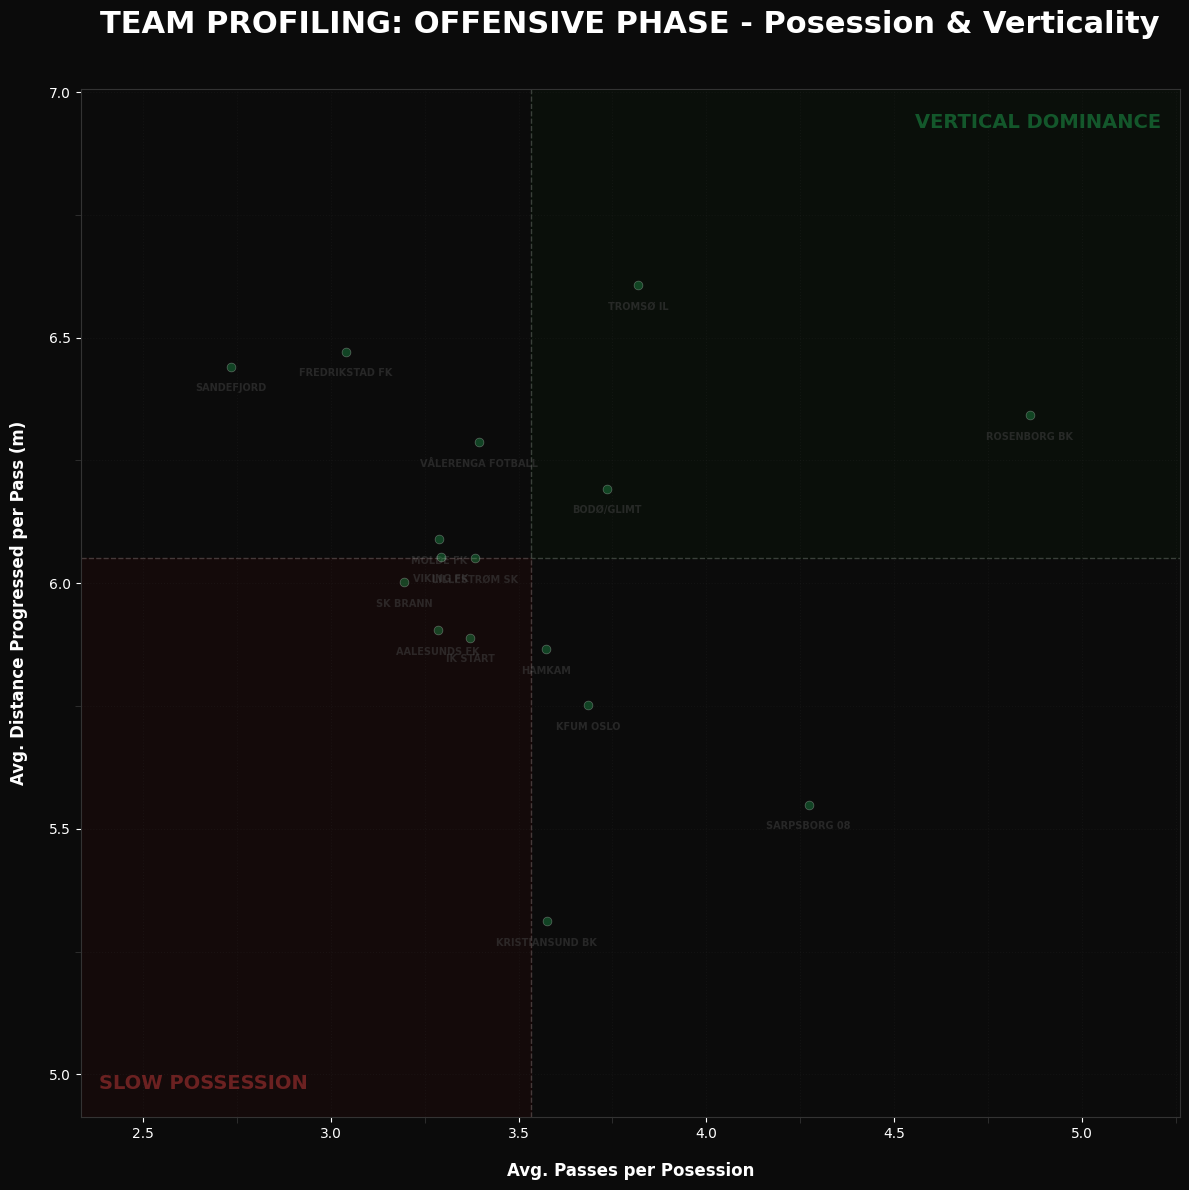

In [ ]:
import matplotlib.ticker as ticker

# ==============================================================================
# 2. PRO-CANVAS: PREPARED FOR LOGO OVERLAY
# ==============================================================================

fig, ax = plt.subplots(figsize=(12, 12), facecolor='#0b0b0b')
ax.set_facecolor('#0b0b0b')

# 1. CUADRANTES (Filtros sutiles)
mean_x = df_scatter['x'].mean()
mean_y = df_scatter['y'].mean()
# Márgenes para que el gráfico respire
max_x, min_x = df_scatter['x'].max() + 0.4, df_scatter['x'].min() - 0.4
max_y, min_y = df_scatter['y'].max() + 0.4, df_scatter['y'].min() - 0.4

ax.axvspan(mean_x, max_x, ymin=(mean_y - min_y)/(max_y - min_y), ymax=1,
           color='green', alpha=0.04, zorder=1)
ax.axvspan(min_x, mean_x, ymin=0, ymax=(mean_y - min_y)/(max_y - min_y),
           color='red', alpha=0.04, zorder=1)

# 2. DATOS: Puntos y Nombres MINIMALISTAS (Para poner logos encima)
# Reducimos el tamaño (s=40) y la opacidad de los nombres
ax.scatter(df_scatter['x'], df_scatter['y'], s=40, c='#22c55e',
           edgecolors='white', linewidth=0.5, alpha=0.3, zorder=3)

for i, row in df_scatter.iterrows():
    ax.text(row['x'], row['y'] - 0.05, row['Team_Clean'].upper(),
            color='#444444', ha='center', fontsize=7, fontweight='bold', zorder=2, alpha=0.5)

# 3. LÍNEAS DE MEDIA
ax.axvline(mean_x, color='white', linestyle='--', alpha=0.2, lw=1, zorder=2)
ax.axhline(mean_y, color='white', linestyle='--', alpha=0.2, lw=1, zorder=2)

# 4. TÍTULOS DE CUADRANTES
ax.text(max_x - 0.05, max_y - 0.05, 'VERTICAL DOMINANCE', color='#22c55e',
        fontsize=14, ha='right', va='top', fontweight='black', alpha=0.4)
ax.text(min_x + 0.05, min_y + 0.05, 'SLOW POSSESSION', color='#ef4444',
        fontsize=14, ha='left', va='bottom', fontweight='black', alpha=0.4)

# 5. CONFIGURACIÓN DE EJES (MÁXIMA PRECISIÓN)

# Eje X: Marcas cada .25, Números cada .5
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

# Eje Y: Marcas cada .25, Números cada .5 (Como pediste)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)

# Etiquetas de Ejes
ax.set_xlabel('Avg. Passes per Posession',
              color='white', fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('Avg. Distance Progressed per Pass (m)',
              color='white', fontsize=12, fontweight='bold', labelpad=15)

# Estética de Ticks y Grid
ax.tick_params(which='major', colors='white', labelsize=10)
ax.tick_params(which='minor', colors='#333333', size=4) # Marcas pequeñas sin número
ax.grid(color='#333333', linestyle=':', alpha=0.2, which='both') # Grid en todas las marcas

for spine in ax.spines.values(): spine.set_edgecolor('#333333')

plt.title('TEAM PROFILING: OFFENSIVE PHASE - Posession & Verticality',
          color='white', fontsize=22, fontweight='black', pad=40)

plt.tight_layout()
plt.show()

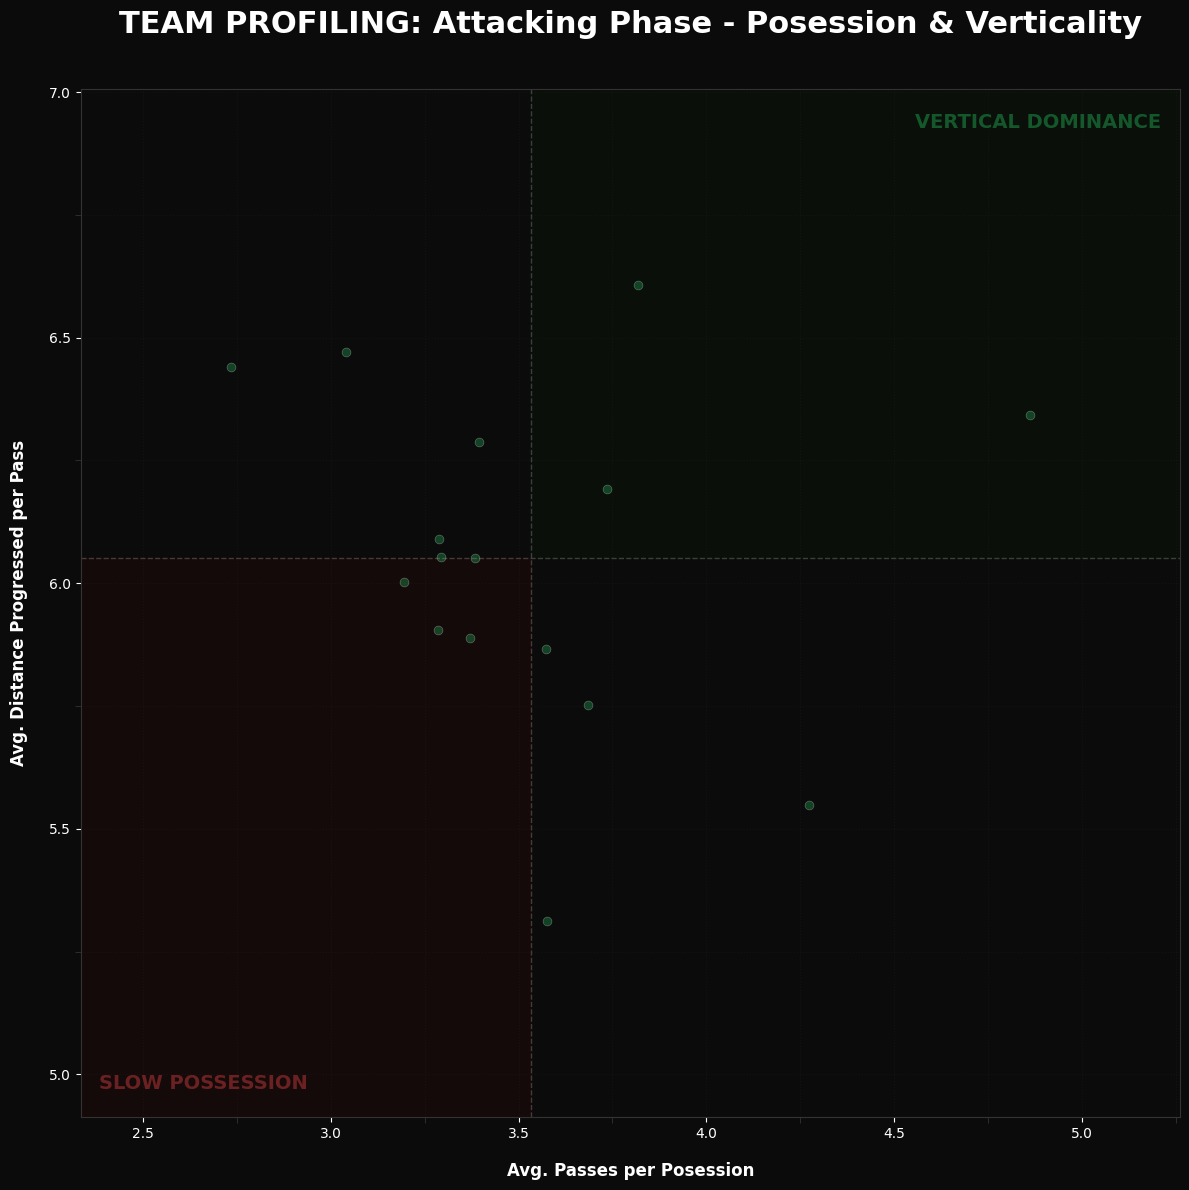

In [ ]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

# ==============================================================================
# 2. ULTRACLEAN CANVAS: PREPARED FOR LOGO OVERLAY (NO NAMES)
# ==============================================================================

fig, ax = plt.subplots(figsize=(12, 12), facecolor='#0b0b0b')
ax.set_facecolor('#0b0b0b')

# 1. CUADRANTES (Filtros sutiles) - Mantener opacidad muy baja (0.04)
mean_x = df_scatter['x'].mean()
mean_y = df_scatter['y'].mean()
max_x, min_x = df_scatter['x'].max() + 0.4, df_scatter['x'].min() - 0.4
max_y, min_y = df_scatter['y'].max() + 0.4, df_scatter['y'].min() - 0.4

ax.axvspan(mean_x, max_x, ymin=(mean_y - min_y)/(max_y - min_y), ymax=1,
           color='green', alpha=0.04, zorder=1)
ax.axvspan(min_x, mean_x, ymin=0, ymax=(mean_y - min_y)/(max_y - min_y),
           color='red', alpha=0.04, zorder=1)

# 2. DATOS: Puntos MINIMALISTAS y GUÍAS DE POSICIÓN (Opacidad 0.3)
# Reducimos el tamaño (s=40) y la opacidad para que sean solo guías
ax.scatter(df_scatter['x'], df_scatter['y'], s=40, c='#22c55e',
           edgecolors='white', linewidth=0.5, alpha=0.3, zorder=3)

# --- BUCLE DE NOMBRES ELIMINADO ---
# Se han quitado las etiquetas de texto de los equipos para dejar el lienzo limpio.

# 3. LÍNEAS DE MEDIA (Opacidad baja 0.2)
ax.axvline(mean_x, color='white', linestyle='--', alpha=0.2, lw=1, zorder=2)
ax.axhline(mean_y, color='white', linestyle='--', alpha=0.2, lw=1, zorder=2)

# 4. TÍTULOS DE CUADRANTES (Opacidad baja 0.4)
ax.text(max_x - 0.05, max_y - 0.05, 'VERTICAL DOMINANCE', color='#22c55e',
        fontsize=14, ha='right', va='top', fontweight='black', alpha=0.4)
ax.text(min_x + 0.05, min_y + 0.05, 'SLOW POSSESSION', color='#ef4444',
        fontsize=14, ha='left', va='bottom', fontweight='black', alpha=0.4)

# 5. CONFIGURACIÓN DE EJES (MÁXIMA PRECISIÓN)

# Eje X: Marcas cada .25, Números cada .5
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

# Eje Y: Marcas cada .25, Números cada .5
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)

# Etiquetas de Ejes (Inglés con Subtítulos)
ax.set_xlabel('Avg. Passes per Posession',
              color='white', fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('Avg. Distance Progressed per Pass',
              color='white', fontsize=12, fontweight='bold', labelpad=15)

# Estética de Ticks y Grid (Sutil 0.2)
ax.tick_params(which='major', colors='white', labelsize=10)
ax.tick_params(which='minor', colors='#333333', size=4)
ax.grid(color='#333333', linestyle=':', alpha=0.2, which='both')

for spine in ax.spines.values(): spine.set_edgecolor('#333333')

plt.title('TEAM PROFILING: Attacking Phase - Posession & Verticality',
          color='white', fontsize=22, fontweight='black', pad=40)

plt.tight_layout()
plt.show()

New visualization: KP Passes Opp. Box

/tmp/ipykernel_5542/1529577315.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eventos['is_pass_to_box'] = (df_eventos['typeId'] == 1) & (df_eventos['outcome'] == 1) & \
/tmp/ipykernel_5542/1529577315.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eventos['is_key_pass'] = (df_eventos['typeId'] == 1) & (df_eventos['outcome'] == 1) & (df_eventos['keyPass'] == True)
/tmp/ipykernel_5542/1529577315.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

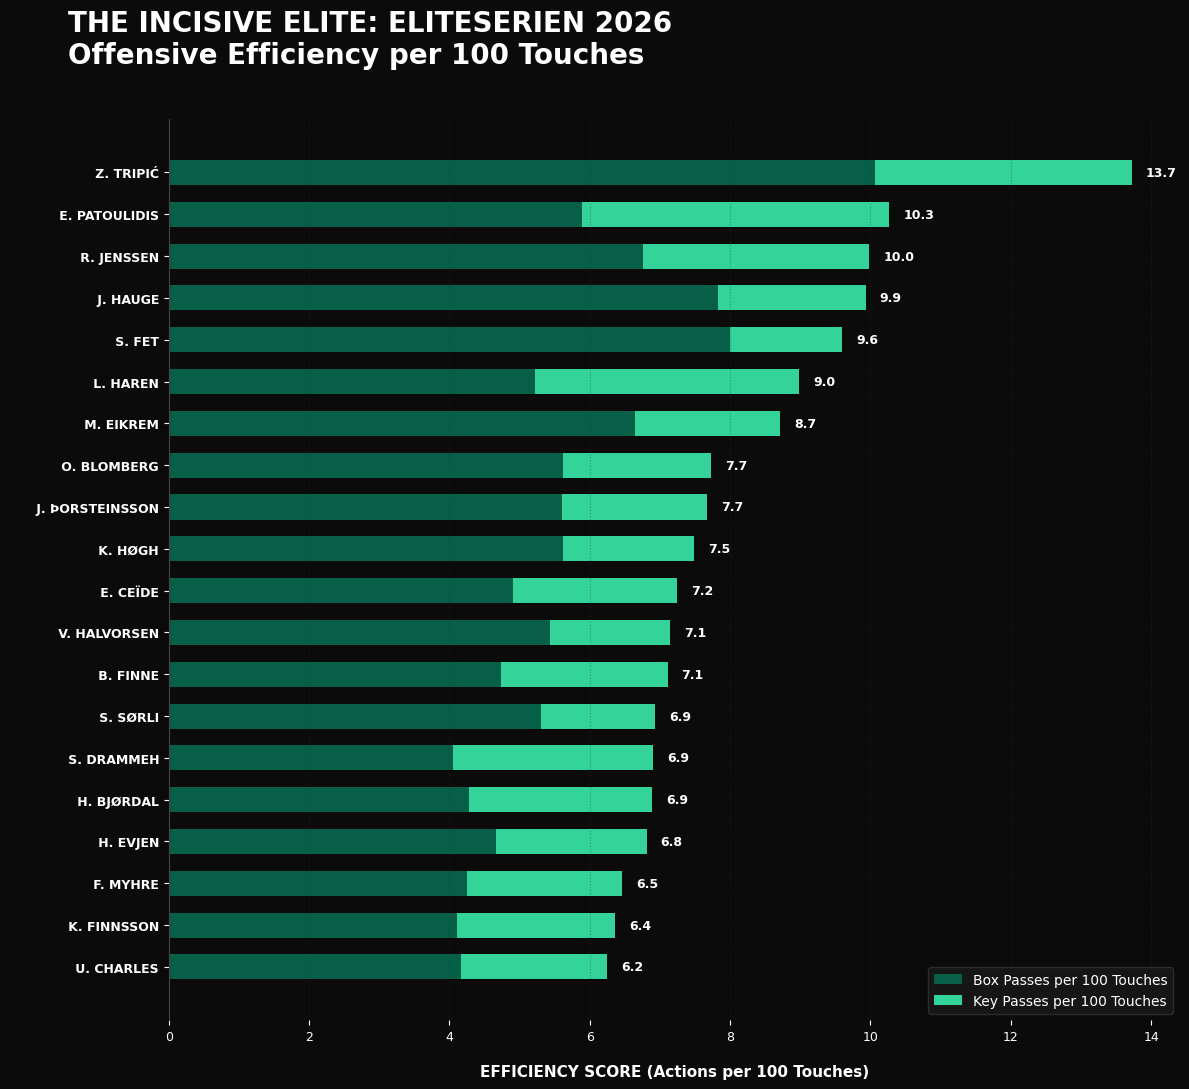

In [ ]:
# ==============================================================================
# 4. INDIVIDUAL EFFICIENCY: TOP 20 GENERATORS PER 100 TOUCHES (FIXED)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# --- PASO PREVIO: Asegurar que las columnas existen tras el reinicio ---
if 'df_eventos' in locals():
    # Definimos pases al área (x_dest >= 83 y y en zona central)
    # Correcting 'x_dest' and 'y_dest' to use 'qualifier_140' and 'qualifier_141'
    df_eventos['is_pass_to_box'] = (df_eventos['typeId'] == 1) & (df_eventos['outcome'] == 1) & \
                                   (df_eventos['qualifier_140'] >= 83) & (df_eventos['qualifier_141'] >= 21.1) & \
                                   (df_eventos['qualifier_141'] <= 78.9)

    # Definimos pases clave (usando el flag keyPass de Opta)
    if 'keyPass' in df_eventos.columns:
        df_eventos['is_key_pass'] = (df_eventos['typeId'] == 1) & (df_eventos['outcome'] == 1) & (df_eventos['keyPass'] == True)
    else:
        # Fallback si no tienes la columna: pases que terminan en tiro (asumiendo orden cronológico)
        df_eventos['is_key_pass'] = (df_eventos['typeId'] == 1) & (df_eventos['outcome'] == 1) & (df_eventos.shift(-1)['typeId'] == 16)

    # 1. Contar Toques Totales por Jugador
    df_toques = df_eventos.groupby(['playerName', 'Team_Clean']).size().reset_index(name='total_touches')

    # 2. Agrupar métricas de ataque
    df_ataque = df_eventos.groupby(['playerName', 'Team_Clean']).agg(
        passes_to_box=('is_pass_to_box', 'sum'),
        key_passes=('is_key_pass', 'sum')
    ).reset_index()

    # 3. Unir y Aplicar Fórmula de Eficiencia
    df_eff = pd.merge(df_ataque, df_toques, on=['playerName', 'Team_Clean'])

    # Filtro de seguridad: mínimo 200 toques para evitar que alguien con 2 pases y 1 al área lidere
    df_eff = df_eff[df_eff['total_touches'] >= 200].copy()

    df_eff['box_eff'] = (df_eff['passes_to_box'] / df_eff['total_touches']) * 100
    df_eff['key_eff'] = (df_eff['key_passes'] / df_eff['total_touches']) * 100
    df_eff['total_eff'] = df_eff['box_eff'] + df_eff['key_eff']

    # Top 20 ordenado por eficiencia total
    df_top20_eff = df_eff.sort_values('total_eff', ascending=False).head(20).copy()
    df_top20_eff = df_top20_eff.iloc[::-1] # Invertir para que el mejor esté arriba

    # 4. VISUALIZACIÓN
    fig, ax = plt.subplots(figsize=(12, 11), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')

    # Barras apiladas (Verde Bosque y Verde Menta)
    ax.barh(df_top20_eff['playerName'], df_top20_eff['box_eff'],
            color='#065f46', label='Box Passes per 100 Touches', height=0.6)

    ax.barh(df_top20_eff['playerName'], df_top20_eff['key_eff'],
            left=df_top20_eff['box_eff'], color='#34d399', label='Key Passes per 100 Touches', height=0.6)

    # Estética
    ax.set_xlabel('EFFICIENCY SCORE (Actions per 100 Touches)', color='white', fontsize=11, fontweight='bold', labelpad=15)
    ax.tick_params(colors='white', labelsize=9)
    ax.set_yticklabels([f"      {name.upper()}" for name in df_top20_eff['playerName']],
                       color='white', fontweight='black')

    # Valores numéricos al final
    for i, val in enumerate(df_top20_eff['total_eff']):
        ax.text(val + 0.2, i, f"{val:.1f}", color='white', va='center', fontsize=9, fontweight='bold')

    # Grid y Leyenda
    ax.grid(axis='x', color='#333333', linestyle=':', alpha=0.4)
    for spine in ['top', 'right', 'bottom']: ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#444444')
    ax.legend(loc='lower right', facecolor='#1a1a1a', edgecolor='#333333', labelcolor='white')

    plt.title('THE INCISIVE ELITE: ELITESERIEN 2026\nOffensive Efficiency per 100 Touches',
              color='white', fontsize=20, fontweight='black', pad=40, x=-0.1, ha='left')

    plt.tight_layout()
    plt.show()
else:
    print("🚨 ERROR: 'df_eventos' no está en memoria. Por favor, ejecuta la celda de carga de datos primero.")

/tmp/ipykernel_5542/1941810398.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eventos['Team_Fixed'] = df_eventos['playerName'].map(player_team_map)


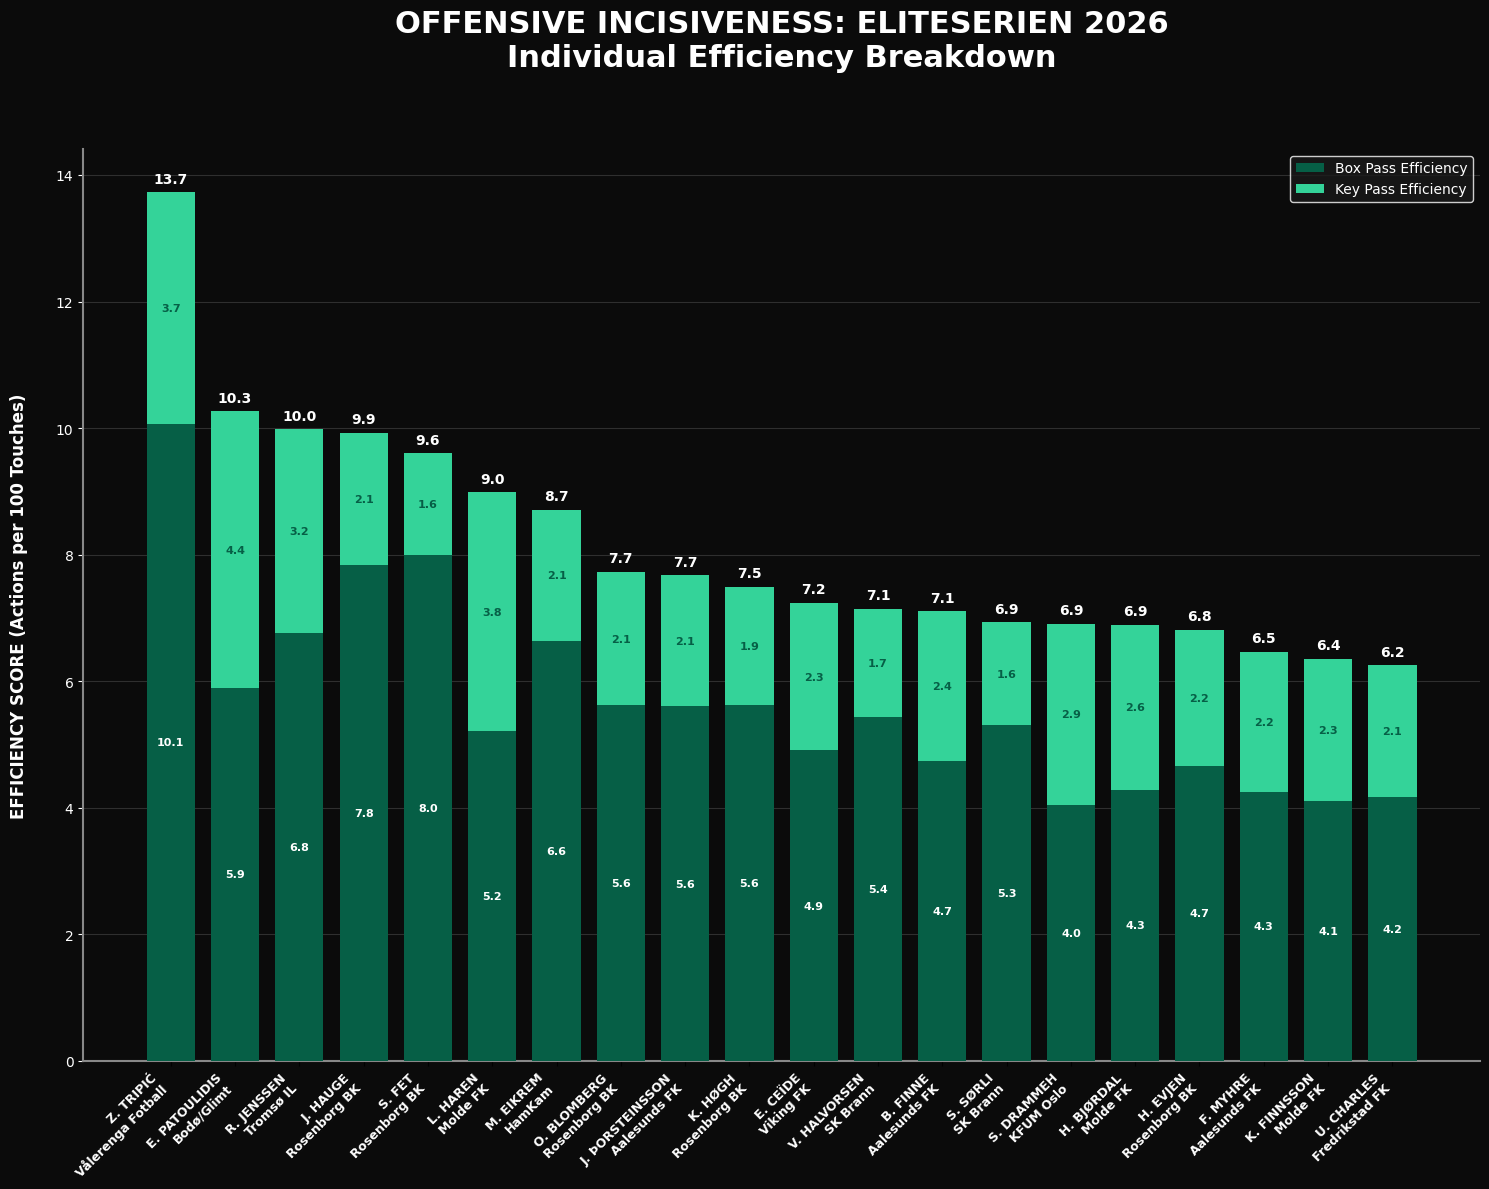

In [ ]:
# ==============================================================================
# 4. FINAL PERFORMANCE INFOGRAPHIC: DATA INTEGRITY & HIGH CONTRAST
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. LIMPIEZA DE DATOS (Fijar Jugador a su equipo principal) ---
# Paso A: Encontrar el equipo donde cada jugador tiene más registros
player_team_map = df_eventos.groupby('playerName')['Team_Clean'].agg(lambda x: x.value_counts().index[0]).to_dict()

# Paso B: Aplicar ese equipo de forma global al dataframe
df_eventos['Team_Fixed'] = df_eventos['playerName'].map(player_team_map)

# --- 2. CÁLCULO DE MÉTRICAS ---
# Toques totales por jugador usando el equipo fijado
df_toques = df_eventos.groupby(['playerName', 'Team_Fixed']).size().reset_index(name='total_touches')

# Agrupar métricas de peligro
df_ataque = df_eventos.groupby(['playerName', 'Team_Fixed']).agg(
    passes_to_box=('is_pass_to_box', 'sum'),
    key_passes=('is_key_pass', 'sum')
).reset_index()

# Unión y Aplicación de Fórmula
df_eff = pd.merge(df_ataque, df_toques, on=['playerName', 'Team_Fixed'])
df_eff = df_eff[df_eff['total_touches'] >= 200].copy()

df_eff['box_eff'] = (df_eff['passes_to_box'] / df_eff['total_touches']) * 100
df_eff['key_eff'] = (df_eff['key_passes'] / df_eff['total_touches']) * 100
df_eff['total_eff'] = df_eff['box_eff'] + df_eff['key_eff']

# Top 20 Definitivo
df_top20_eff = df_eff.sort_values('total_eff', ascending=False).head(20).copy()

# --- 3. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(15, 12), facecolor='#0b0b0b')
ax.set_facecolor('#0b0b0b')

x_pos = range(len(df_top20_eff))

# Barras con mayor contraste
ax.bar(x_pos, df_top20_eff['box_eff'], color='#065f46',
       label='Box Pass Efficiency', width=0.75, alpha=1, zorder=3)

ax.bar(x_pos, df_top20_eff['key_eff'], bottom=df_top20_eff['box_eff'],
       color='#34d399', label='Key Pass Efficiency', width=0.75, alpha=1, zorder=3)

# Valores internos (Fórmula parcial)
for i, (idx, row) in enumerate(df_top20_eff.iterrows()):
    if row['box_eff'] > 0.4:
        ax.text(i, row['box_eff']/2, f"{row['box_eff']:.1f}",
                color='white', ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)
    if row['key_eff'] > 0.3:
        ax.text(i, row['box_eff'] + (row['key_eff']/2), f"{row['key_eff']:.1f}",
                color='#065f46', ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)
    # Total destacado
    ax.text(i, row['total_eff'] + 0.15, f"{row['total_eff']:.1f}",
            color='white', ha='center', fontsize=10, fontweight='black', zorder=5)

# --- 4. CONFIGURACIÓN DE EJES Y CUADRÍCULA ---
# Cuadrícula notable (Blanca, sólida y detrás de las barras)
ax.grid(axis='y', color='white', linestyle='-', alpha=0.15, zorder=0)

# Bordes del gráfico (Ejes X e Y visibles)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#888888')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#888888')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Etiquetas de Eje X (Nombres y Equipos)
ax.set_xticks(x_pos)
labels = [f"{row['playerName'].upper()}\n{row['Team_Fixed']}" for _, row in df_top20_eff.iterrows()]
ax.set_xticklabels(labels, color='white', rotation=45, ha='right', fontsize=9, fontweight='bold')

# Etiquetas de Eje Y
ax.tick_params(axis='y', colors='white', labelsize=10)
ax.set_ylabel('EFFICIENCY SCORE (Actions per 100 Touches)', color='white', fontsize=12, fontweight='black', labelpad=20)

# Título y Leyenda
plt.title('OFFENSIVE INCISIVENESS: ELITESERIEN 2026\nIndividual Efficiency Breakdown',
          color='white', fontsize=22, fontweight='black', pad=60, loc='center')

ax.legend(loc='upper right', facecolor='#1a1a1a', edgecolor='white', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.show()

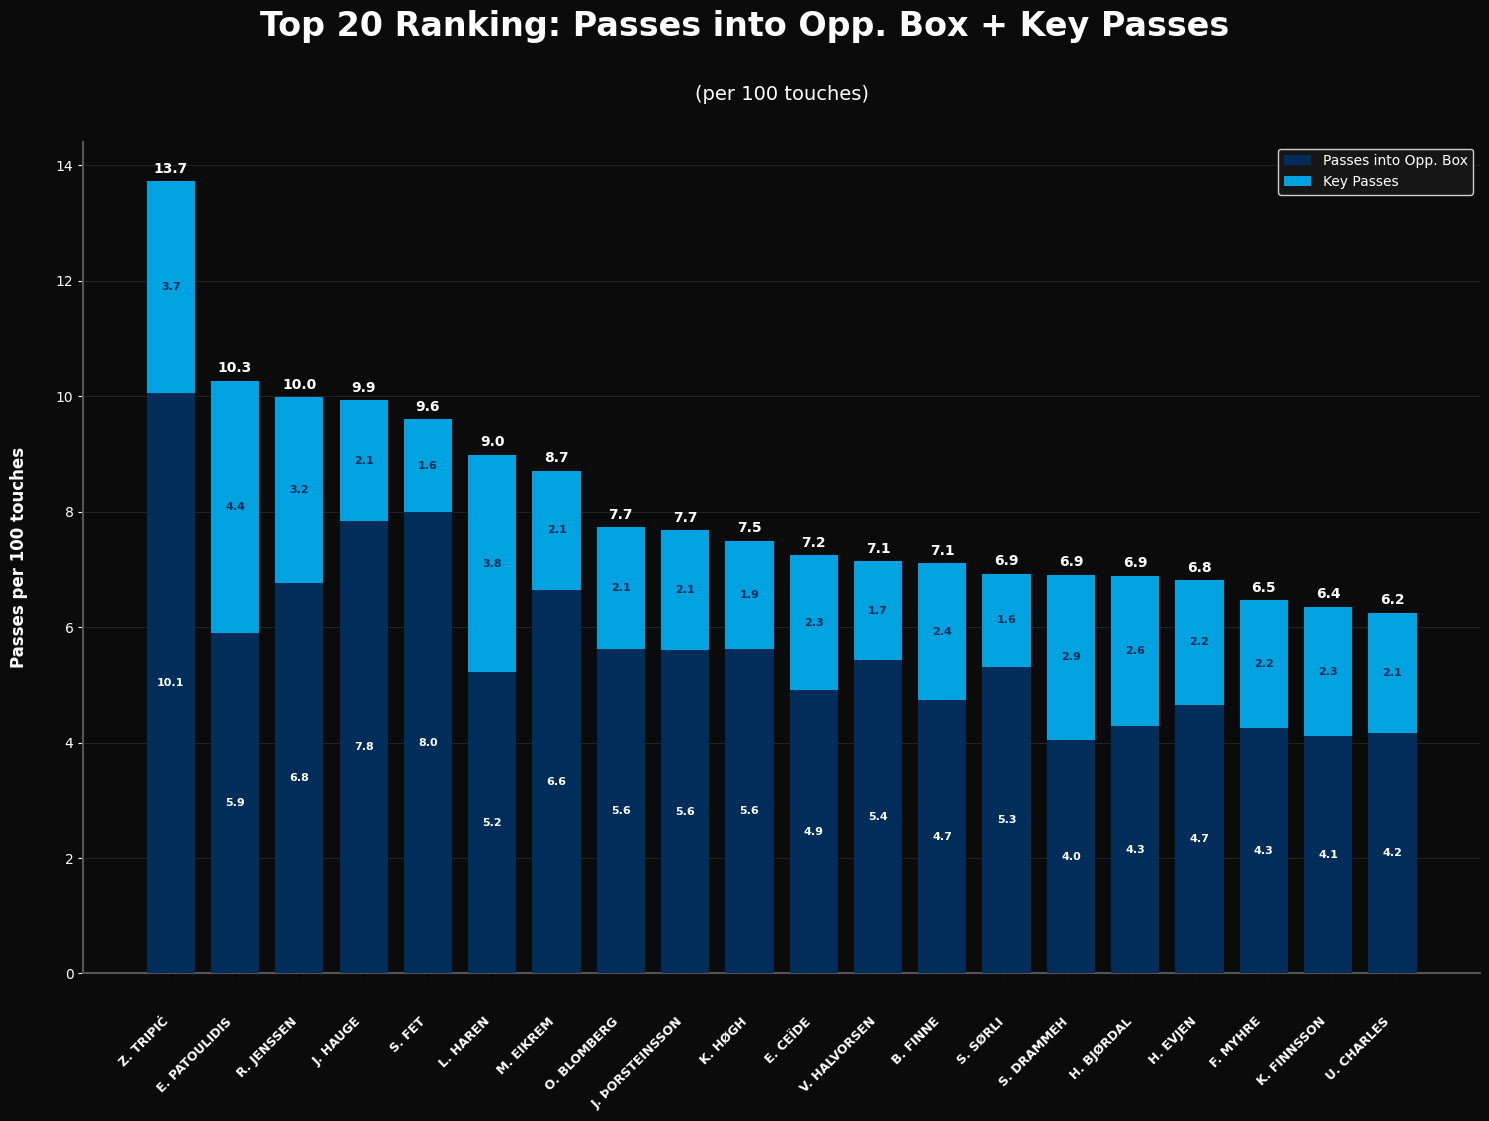

In [ ]:
# ==============================================================================
# 4. FINAL INDIVIDUAL INFOGRAPHIC: ELITESERIEN BLUE EDITION
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CÁLCULO DE MÉTRICAS (Lógica de Eficiencia) ---
df_toques = df_eventos.groupby('playerName').size().reset_index(name='total_touches')

df_ataque = df_eventos.groupby('playerName').agg(
    passes_to_box=('is_pass_to_box', 'sum'),
    key_passes=('is_key_pass', 'sum')
).reset_index()

df_eff = pd.merge(df_ataque, df_toques, on='playerName')
df_eff = df_eff[df_eff['total_touches'] >= 200].copy()

df_eff['box_eff'] = (df_eff['passes_to_box'] / df_eff['total_touches']) * 100
df_eff['key_eff'] = (df_eff['key_passes'] / df_eff['total_touches']) * 100
df_eff['total_eff'] = df_eff['box_eff'] + df_eff['key_eff']

df_top20_eff = df_eff.sort_values('total_eff', ascending=False).head(20).copy()

# --- 2. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(15, 12), facecolor='#0b0b0b')
ax.set_facecolor('#0b0b0b')

x_pos = range(len(df_top20_eff))

color_marino = '#002d5a'
color_cielo = '#00a3e0'

# Barras Apiladas
ax.bar(x_pos, df_top20_eff['box_eff'], color=color_marino,
       label='Passes into Opp. Box', width=0.75, alpha=1, zorder=3)

ax.bar(x_pos, df_top20_eff['key_eff'], bottom=df_top20_eff['box_eff'],
       color=color_cielo, label='Key Passes', width=0.75, alpha=1, zorder=3)

# --- 3. VALORES INTERNOS ---
for i, (idx, row) in enumerate(df_top20_eff.iterrows()):
    if row['box_eff'] > 0.4:
        ax.text(i, row['box_eff']/2, f"{row['box_eff']:.1f}",
                color='white', ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)
    if row['key_eff'] > 0.3:
        ax.text(i, row['box_eff'] + (row['key_eff']/2), f"{row['key_eff']:.1f}",
                color=color_marino, ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)
    ax.text(i, row['total_eff'] + 0.15, f"{row['total_eff']:.1f}",
            color='white', ha='center', fontsize=10, fontweight='black', zorder=5)

# --- 4. CONFIGURACIÓN DE EJES Y CUADRÍCULA ---
ax.grid(axis='y', color='white', linestyle='-', alpha=0.1, zorder=0)

ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#555555')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#555555')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks(x_pos)
nombres_limpios = [f"\n\n\n{name.upper()}" for name in df_top20_eff['playerName']]
ax.set_xticklabels(nombres_limpios, color='white', rotation=45, ha='right', fontsize=9, fontweight='black')

ax.tick_params(axis='y', colors='white', labelsize=10)
ax.set_ylabel('Passes per 100 touches', color='white', fontsize=12, fontweight='black', labelpad=20)

# --- 5. TÍTULO Y LEYENDA (MODIFICADO PARA TÍTULO + SUBTÍTULO) ---
# Título principal (Grande)
plt.suptitle('Top 20 Ranking: Passes into Opp. Box + Key Passes',
             color='white', fontsize=24, fontweight='black', y=0.96)

# Subtítulo (Más pequeño y justo debajo)
ax.set_title('(per 100 touches)', color='white', fontsize=14, fontweight='normal', pad=30)

ax.legend(loc='upper right', facecolor='#1a1a1a', edgecolor='white', labelcolor='white', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustamos el layout para que no choque con suptitle
plt.show()

Defensive Graph

In [ ]:
# Test para buscar eventos de sustitución
posibles_cambios = df_eventos[df_eventos['typeId'].isin([40, 41, 18, 19])] # IDs comunes de cambios
print(f"Se han encontrado {len(posibles_cambios)} eventos de posible sustitución.")
if len(posibles_cambios) > 0:
    print(posibles_cambios[['timeMin', 'playerName', 'typeId']].head())

Se han encontrado 1261 eventos de posible sustitución.
      timeMin        playerName  typeId
885        45               NaN      40
1134       56  O. Øhlenschlæger      18
1135       56          L. Owusu      19
1136       56      S. Laghzaoui      18
1137       56          J. Nuñez      19


In [ ]:
# VERSIÓN RÁPIDA (Vectorizada) por si la anterior tarda demasiado
def calcular_minutos_fast(df):
    # 1. Identificar últimos minutos de cada jugador
    tiempos = df.groupby('playerName')['timeMin'].agg(['min', 'max']).reset_index()

    # 2. Ajuste inteligente:
    # Si empezó antes del min 10, asumimos min 0.
    # Si terminó después del min 85, asumimos min 95.
    tiempos['start'] = tiempos['min'].apply(lambda x: 0 if x < 10 else x)
    tiempos['end'] = tiempos['max'].apply(lambda x: 95 if x > 85 else x)

    tiempos['minutes_played'] = tiempos['end'] - tiempos['start']
    return tiempos[['playerName', 'minutes_played']]

In [ ]:
# ==============================================================================
# 5. DEFENSIVE PERFORMANCE: ROBUST LOLLIPOP (ANTI-ERROR VERSION)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# 1. Verificación de seguridad de datos
if 'df_eventos' not in locals():
    print("🚨 df_eventos no está cargado. Por favor, ejecuta la celda de carga de datos.")
else:
    df = df_eventos.copy()

    # Identificar columna de coordenadas (puede ser 'x' o 'startX')
    x_col = 'x' if 'x' in df.columns else ('startX' if 'startX' in df.columns else None)

    if x_col is None:
        print("🚨 No se encontró columna de coordenadas X.")
    else:
        # 2. Definición de métrica: Tackles(7), Intercepciones(8) y Recuperaciones(49) exitosas
        # Filtramos por éxito (outcome == 1) y zona rival (> 66.6)
        df['is_def_high'] = (df['typeId'].isin([7, 8, 49])) & (df['outcome'] == 1) & (df[x_col] > 66.6)

        # 3. Cálculo de minutos (Aseguramos que existan)
        tiempos = df.groupby('playerName')['timeMin'].agg(['min', 'max']).reset_index()
        tiempos['minutes_played'] = tiempos['max'] - tiempos['min']
        tiempos.loc[tiempos['minutes_played'] < 1, 'minutes_played'] = 1

        # 4. Agrupación y Filtro de Minutos
        df_def = df.groupby('playerName').agg(total_def=('is_def_high', 'sum')).reset_index()
        df_final = pd.merge(df_def, tiempos, on='playerName')

        # Bajamos el filtro a 180 minutos (2 partidos) para asegurar que pinte algo
        df_final = df_final[df_final['minutes_played'] >= 180].copy()

        # Cálculo p90
        df_final['p90'] = (df_final['total_def'] / df_final['minutes_played']) * 90

        # Ordenar y sacar Top 20
        df_top20 = df_final.sort_values('p90', ascending=True).tail(20)

        if df_top20.empty or df_top20['total_def'].sum() == 0:
            print("🚨 Datos no encontrados. Posibles causas:")
            print(f"- Hay {df['is_def_high'].sum()} acciones defensivas en campo rival registradas.")
            print(f"- Hay {len(df_final)} jugadores con más de 180 minutos.")
        else:
            # --- 5. VISUALIZACIÓN LOLLIPOP ---
            fig, ax = plt.subplots(figsize=(12, 12), facecolor='#0b0b0b')
            ax.set_facecolor('#0b0b0b')

            y_pos = range(len(df_top20))
            color_cielo = '#00a3e0'

            # Líneas y Círculos
            ax.hlines(y=y_pos, xmin=0, xmax=df_top20['p90'], color='#555555', linewidth=2, alpha=0.6)
            ax.scatter(df_top20['p90'], y_pos, s=700, color=color_cielo, edgecolors='white', linewidth=1.5, zorder=3)

            # Texto dentro del círculo
            for i, val in enumerate(df_top20['p90']):
                ax.text(val, i, f"{val:.1f}", color='white', va='center', ha='center',
                        fontsize=9, fontweight='black', zorder=4)

            # Estética de Ejes
            ax.set_yticks(y_pos)
            ax.set_yticklabels([f"{name.upper()}      " for name in df_top20['playerName']],
                               color='white', fontsize=10, fontweight='bold')

            ax.set_xlabel('Defensive Actions (Recoveries + Tackles + Int.) per 90 Min',
                          color='white', fontsize=11, fontweight='bold', labelpad=20)

            # Cuadrícula y Limpieza
            ax.grid(axis='x', color='white', linestyle='--', alpha=0.1, zorder=0)
            ax.spines['bottom'].set_color('#555555')
            ax.spines['left'].set_color('#555555')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='x', colors='white')

            # Título y Subtítulo
            plt.suptitle('TOP 20 HIGH PRESSING SPECIALISTS',
                         color='white', fontsize=22, fontweight='black', y=0.96)
            ax.set_title('Successful actions in Final Third (per 90 minutes)',
                         color='#888888', fontsize=14, fontweight='normal', pad=30)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

🚨 Datos no encontrados. Posibles causas:
- Hay 799 acciones defensivas en campo rival registradas.
- Hay 0 jugadores con más de 180 minutos.


Final Version:

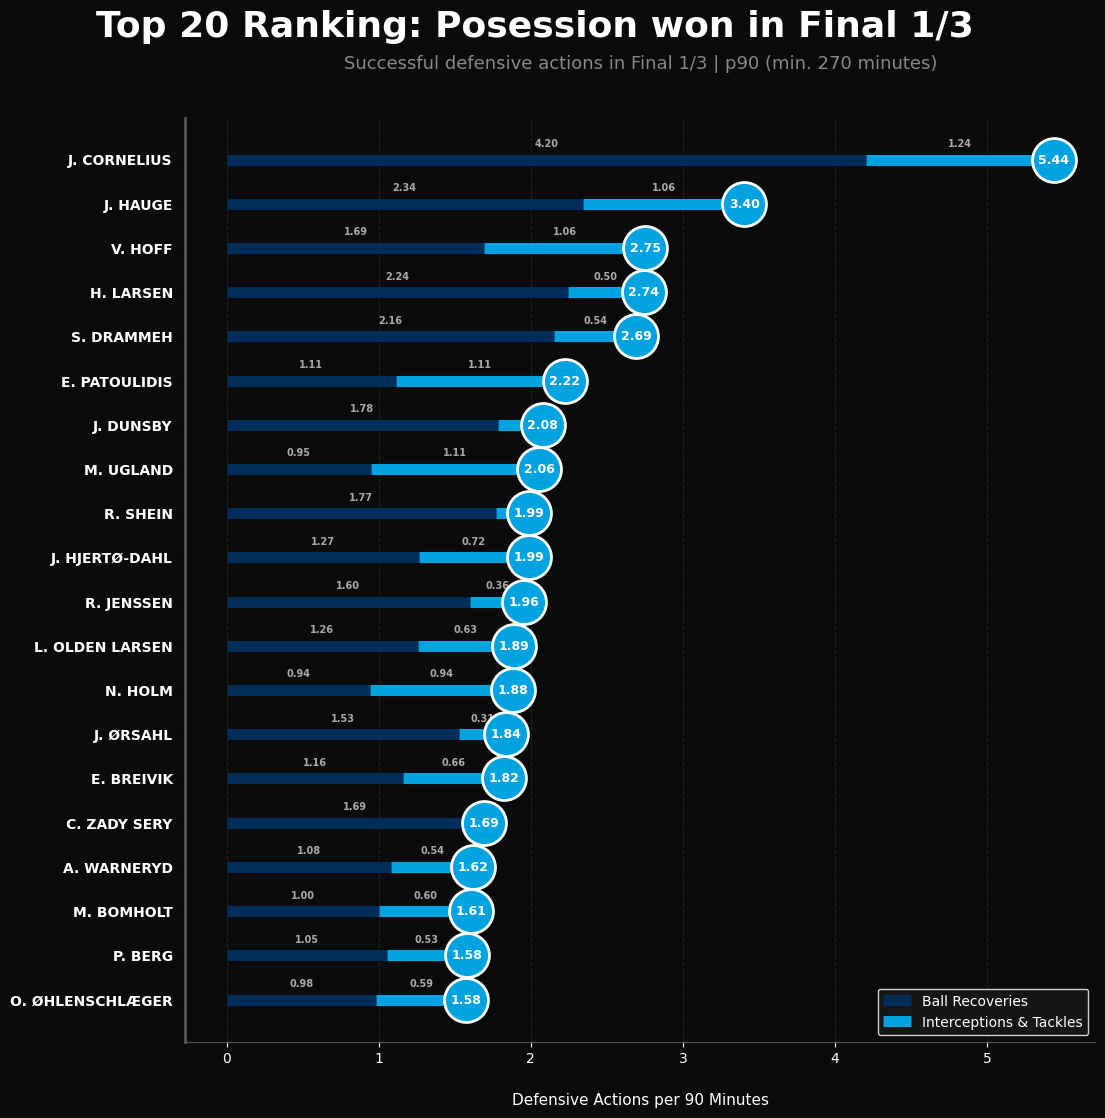

In [ ]:
# ==============================================================================
# 5. DEFENSIVE PERFORMANCE: FINAL STACKED LOLLIPOP WITH INTERNAL LABELS
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# 1. ORDENAR DATOS (Top 20 por total_p90)
df_top20 = df_res.sort_values('total_p90', ascending=True).tail(20)

# 2. VISUALIZACIÓN
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#0b0b0b')
ax.set_facecolor('#0b0b0b')

y_pos = range(len(df_top20))
color_marino = '#002d5a'
color_cielo = '#00a3e0'

# Dibujamos los palos apilados (Grosor 8 para que el texto quepa mejor encima/dentro)
ax.hlines(y=y_pos, xmin=0, xmax=df_top20['rec_p90'],
          color=color_marino, linewidth=8, alpha=1, zorder=3)

ax.hlines(y=y_pos, xmin=df_top20['rec_p90'], xmax=df_top20['total_p90'],
          color=color_cielo, linewidth=8, alpha=1, zorder=3)

# El "Caramelo" final
ax.scatter(df_top20['total_p90'], y_pos, s=1000, color=color_cielo,
           edgecolors='white', linewidth=2, zorder=5)

# --- 3. ETIQUETAS DE VALORES PARCIALES (p90) ---
for i, (idx, row) in enumerate(df_top20.iterrows()):
    # Valor de Recuperaciones (sobre el tramo marino)
    if row['rec_p90'] > 0.3: # Solo si el tramo es lo bastante largo
        ax.text(row['rec_p90']/2, i + 0.25, f"{row['rec_p90']:.2f}",
                color='#aaaaaa', ha='center', va='bottom', fontsize=7, fontweight='bold')

    # Valor de Interceptaciones/Tackles (sobre el tramo cielo)
    if row['int_p90'] > 0.3:
        ax.text(row['rec_p90'] + (row['int_p90']/2), i + 0.25, f"{row['int_p90']:.2f}",
                color='#aaaaaa', ha='center', va='bottom', fontsize=7, fontweight='bold')

    # TOTAL (Dentro del círculo)
    ax.text(row['total_p90'], i, f"{row['total_p90']:.2f}",
            color='white', va='center', ha='center', fontsize=9, fontweight='black', zorder=6)

# --- 4. AJUSTE DE EJES (Máxima cercanía para escudos) ---
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{name.upper()} " for name in df_top20['playerName']],
                   color='white', fontsize=10, fontweight='black', ha='right')

# Dejamos el margen izquierdo amplio (0.25) para los logos
plt.subplots_adjust(left=0.25)
ax.tick_params(axis='y', which='major', pad=2) # Pegado casi total a la línea

# --- 5. ESTÉTICA Y TÍTULOS ---
ax.set_xlabel('Defensive Actions per 90 Minutes', color='white', fontsize=11, labelpad=20)
ax.grid(axis='x', color='white', linestyle='--', alpha=0.1, zorder=0)

ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#555555')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_color('#555555')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.tick_params(axis='x', colors='white')

plt.suptitle('Top 20 Ranking: Posession won in Final 1/3',
             color='white', fontsize=26, fontweight='black', y=0.97)
ax.set_title('Successful defensive actions in Final 1/3 | p90 (min. 270 minutes)',
             color='#888888', fontsize=13, pad=35)

# Leyenda
ax.legend(['Ball Recoveries', 'Interceptions & Tackles'], loc='lower right',
          facecolor='#1a1a1a', edgecolor='white', labelcolor='white')

plt.show()

#Section 3